ANOVA analysis - vertical difference

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, levene, bartlett, anderson, normaltest

import pingouin as pg
from itertools import combinations
import matplotlib.pyplot as plt

In [2]:
# normality and homogeneity of variance tests for ANOVA assumptions
def check_anova_assumptions(df, group_col, metric_col, group_order=None):
    if group_order is None:
        group_order = df[group_col].unique()

    print(f"\n=== Normality test (D’Agostino and Pearson) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        stat, p = normaltest(data)
        result = "OK normal" if p > 0.05 else "not normal"
        print(f"{group.ljust(25)}:\tp = {p:.4f}\t→\t{result}")

    print(f"\n=== Normality test (Shapiro-Wilk) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        stat, p = shapiro(data)
        result = "OK normal" if p > 0.05 else "not normal"
        print(f"{group.ljust(25)}:\tp = {p:.4f}\t→\t{result}")

    print(f"\n=== Normality test (Anderson-Darling) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        result = anderson(data)
        stat = result.statistic
        crit_5 = result.critical_values[2]
        interpretation = "OK normal" if stat < crit_5 else "not normal"
        print(f"{group.ljust(25)}:\tA² = {stat:.4f},\t5% critical = {crit_5:.4f}\t→\t{interpretation}")

    print(f"\n=== Homogeneity of variance tests for {metric_col} ===")
    groups = [df[df[group_col] == group][metric_col] for group in group_order]

    stat_levene, p_levene = levene(*groups)
    result_levene = "OK equal variances" if p_levene > 0.05 else "unequal variances"
    print(f"Levene’s test  : p = {p_levene:.4f}\t→\t{result_levene}")

    stat_bartlett, p_bartlett = bartlett(*groups)
    result_bartlett = "OK equal variances" if p_bartlett > 0.05 else "unequal variances"
    print(f"Bartlett’s test: p = {p_bartlett:.4f}\t→\t{result_bartlett}")

    # Brown–Forsythe test (Levene with center='median')
    stat_bf, p_bf = levene(*groups, center='median')
    result_bf = "OK equal variances" if p_bf > 0.05 else "unequal variances"
    print(f"Brown–Forsythe : p = {p_bf:.4f}\t→\t{result_bf}")

In [3]:
def interpret_eta2(x: float) -> str:
    if x < 0.01:
        return "negligible"
    elif x < 0.06:
        return "small"
    elif x < 0.14:
        return "medium"
    else:
        return "large"

def interpret_d_like(x: float) -> str:
    ax = abs(x)
    if ax < 0.2:
        return "negligible"
    elif ax < 0.5:
        return "small"
    elif ax < 0.8:
        return "medium"
    else:
        return "large"

In [4]:
# ANOVA with eta squared, Games-Howell posthoc, and pairwise Hedges g effect sizes
def run_anova_full(df, group_col, metric_col, show_ci=True):
    # ===== Welch ANOVA =====
    print(f"\n=== Welch ANOVA for {metric_col} ===")
    welch = pg.welch_anova(dv=metric_col, between=group_col, data=df)
    print(welch.to_string(index=False))

    # Overall effect size (np2) interpretation
    if "np2" in welch.columns:
        np2 = float(welch.loc[0, "np2"])
        print(f"\nEffect size (partial η², np2) = {np2:.4f} → {interpret_eta2(np2)} effect")
    else:
        np2 = None
        print("\nEffect size: np2 not provided by Welch ANOVA output.")

    # ===== Games-Howell post-hoc =====
    print(f"\n=== Games-Howell post-hoc test for {metric_col} ===")
    gh = pg.pairwise_gameshowell(dv=metric_col, between=group_col, data=df).copy()
    print(gh.to_string(index=False))

    # ===== Pairwise effect sizes =====
    print(f"\n=== Pairwise effect sizes for {metric_col} (Hedges' g) ===")
    group_labels = list(pd.unique(df[group_col]))
    label_width = max(len(str(g)) for g in group_labels) + 2

    for g1, g2 in combinations(group_labels, 2):
        x = df.loc[df[group_col] == g1, metric_col].to_numpy()
        y = df.loc[df[group_col] == g2, metric_col].to_numpy()

        g = float(pg.compute_effsize(x, y, eftype="hedges"))
        effect = interpret_d_like(g)

        line = (
            f"{str(g1).ljust(label_width)} vs {str(g2).ljust(label_width)}:"
            f" g = {g:.4f} → {effect} effect"
        )

        if show_ci:
            ci = pg.compute_bootci(
                x, y,
                func=lambda a, b: pg.compute_effsize(a, b, eftype="hedges"),
                confidence=0.95,
                method="percentile",
            )
            line += f"   95% CI [{ci[0]:.4f}, {ci[1]:.4f}]"

        print(line)

## Time independent - A

In [5]:
model = "time independent A CO2 VD"
single_top_co2 = pd.read_csv("../../analysis_sensor_position/_timeindep_results_raw/case_LabEEE_A_top_state_timeindep_co2.csv")
single_low_co2 = pd.read_csv("../../analysis_sensor_position/_timeindep_results_raw/case_LabEEE_A_low_state_timeindep_co2.csv")
dual_co2_only = pd.read_csv("../_timeindep_results_raw/case_LabEEE_A_state_timeindep_co2only.csv")
dual_VD = pd.read_csv("../_timeindep_results_raw/case_LabEEE_A_state_timeindep_VD.csv")
dual_VD_co2 = pd.read_csv("../_timeindep_results_raw/case_LabEEE_A_state_timeindep_VDco2.csv")

In [6]:
single_top_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.895244,0.007351,0.871279,0.889783,0.896219,0.899437,0.913113
f1_weighted,250.0,0.894296,0.007519,0.870192,0.888807,0.895296,0.899030,0.912956
balanced_acc,250.0,0.873503,0.009348,0.844668,0.867040,0.874362,0.879676,0.900783
auc,250.0,0.935845,0.006629,0.916480,0.931622,0.936093,0.940198,0.953458
model_weights.random_forest,250.0,1.382402,0.336463,0.465282,1.125723,1.407841,1.620215,2.368215
model_weights.bagging_svc,250.0,0.147072,0.209864,-0.355506,0.015991,0.154571,0.284115,0.914404
model_weights.bagging_knn,250.0,0.391261,0.192750,-0.243950,0.267855,0.393241,0.519315,1.023723
model_weights.gradient_boosting,250.0,2.075282,0.301574,1.181930,1.885667,2.089954,2.257589,2.857250


In [7]:
single_low_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.882819,0.007715,0.861625,0.877916,0.882542,0.888174,0.902655
f1_weighted,250.0,0.881218,0.007905,0.858804,0.876221,0.881433,0.886578,0.902489
balanced_acc,250.0,0.855663,0.009780,0.826162,0.849280,0.856271,0.862447,0.886216
auc,250.0,0.931682,0.007153,0.911996,0.927256,0.932325,0.937012,0.953967
model_weights.random_forest,250.0,1.166917,0.342587,0.213119,0.940388,1.181224,1.423761,1.968576
model_weights.bagging_svc,250.0,-0.255947,0.159783,-0.687534,-0.360524,-0.261083,-0.148143,0.306334
model_weights.bagging_knn,250.0,0.404255,0.214418,-0.345906,0.276464,0.420849,0.565567,0.925348
model_weights.gradient_boosting,250.0,2.690523,0.274075,1.861925,2.527035,2.684668,2.852975,3.652276


In [8]:
dual_co2_only.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.920895,0.006698,0.898632,0.916533,0.920354,0.925784,0.938053
f1_weighted,250.0,0.920654,0.006768,0.897352,0.916340,0.920190,0.925483,0.938074
balanced_acc,250.0,0.907818,0.008502,0.875044,0.902275,0.907348,0.913569,0.928998
auc,250.0,0.965744,0.004527,0.950009,0.962758,0.966138,0.968842,0.975970
model_weights.random_forest,250.0,1.984437,0.341575,1.252574,1.732751,1.966704,2.225753,2.860917
model_weights.bagging_svc,250.0,-0.352535,0.232011,-1.107856,-0.520635,-0.325336,-0.197302,0.232042
model_weights.bagging_knn,250.0,-0.199053,0.197365,-0.886257,-0.328314,-0.188825,-0.070363,0.383803
model_weights.gradient_boosting,250.0,2.619070,0.302981,1.861116,2.421453,2.639988,2.805914,3.653861


In [9]:
dual_VD.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.856402,0.008828,0.831858,0.850362,0.856798,0.861625,0.880933
f1_weighted,250.0,0.852840,0.009187,0.828457,0.847183,0.853016,0.859048,0.877926
balanced_acc,250.0,0.817599,0.010896,0.783870,0.811082,0.817617,0.824745,0.847729
auc,250.0,0.894344,0.008822,0.869791,0.888034,0.894442,0.900520,0.917595
model_weights.random_forest,250.0,0.716423,0.345229,-0.173061,0.489015,0.712490,0.974622,1.935689
model_weights.bagging_svc,250.0,-0.118514,0.141158,-0.453133,-0.218019,-0.112255,-0.016777,0.225566
model_weights.bagging_knn,250.0,1.377309,0.241376,0.501699,1.213130,1.369843,1.537471,2.155008
model_weights.gradient_boosting,250.0,1.639382,0.374941,0.765273,1.337246,1.674791,1.915784,2.578270


In [10]:
dual_VD_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.923717,0.006854,0.905873,0.918745,0.923572,0.929002,0.939662
f1_weighted,250.0,0.923577,0.006895,0.905419,0.918451,0.923345,0.928588,0.939641
balanced_acc,250.0,0.912125,0.008436,0.888827,0.906300,0.912028,0.918387,0.931726
auc,250.0,0.970347,0.004057,0.956428,0.967849,0.970461,0.973302,0.979495
model_weights.random_forest,250.0,1.468517,0.355207,0.360796,1.264004,1.530945,1.716009,2.338089
model_weights.bagging_svc,250.0,-0.325037,0.252265,-0.930656,-0.495857,-0.324292,-0.172147,0.388923
model_weights.bagging_knn,250.0,-0.392764,0.179888,-0.917098,-0.504974,-0.390013,-0.275454,0.079136
model_weights.gradient_boosting,250.0,4.160141,0.290482,3.230954,3.980105,4.152515,4.364904,5.249239


In [11]:
single_top_co2['case'] = 'single_top_co2'
single_low_co2['case'] = 'single_low_co2'
dual_co2_only['case'] = 'dual_co2_only'
dual_VD['case'] = 'dual_VD'
dual_VD_co2['case'] = 'dual_VD_co2'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        single_top_co2[metrics],
        single_low_co2[metrics],
        dual_co2_only[metrics],
        dual_VD[metrics],
        dual_VD_co2[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1250 non-null   object 
 1   accuracy      1250 non-null   float64
 2   f1_weighted   1250 non-null   float64
 3   balanced_acc  1250 non-null   float64
 4   auc           1250 non-null   float64
dtypes: float64(4), object(1)
memory usage: 49.0+ KB


In [12]:
case_order = ['single_top_co2', 'single_low_co2', 'dual_co2_only', 'dual_VD', 'dual_VD_co2']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,single_top_co2,single_top_co2,single_top_co2,single_top_co2,single_top_co2
accuracy,0.891392,0.895414,0.892196,0.886565,0.90185
f1_weighted,0.891299,0.893618,0.890999,0.885222,0.901108
balanced_acc,0.878622,0.869103,0.869219,0.865848,0.880908
auc,0.934548,0.934756,0.929482,0.94173,0.933862
x,0,0,0,0,0
x_jitter,0.053205,-0.03302,-0.07544,0.024464,-0.038239


### plot

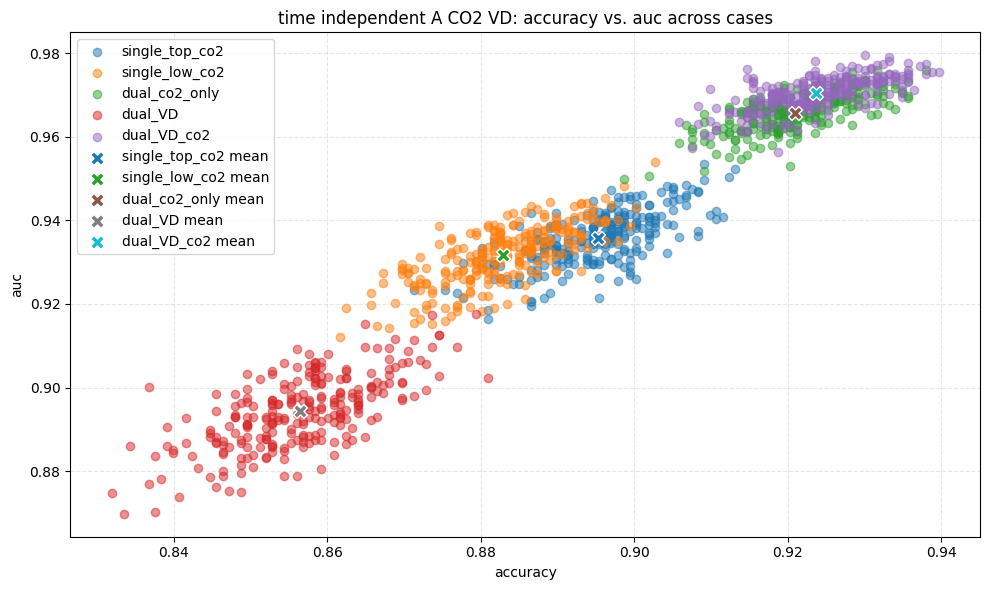

In [13]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

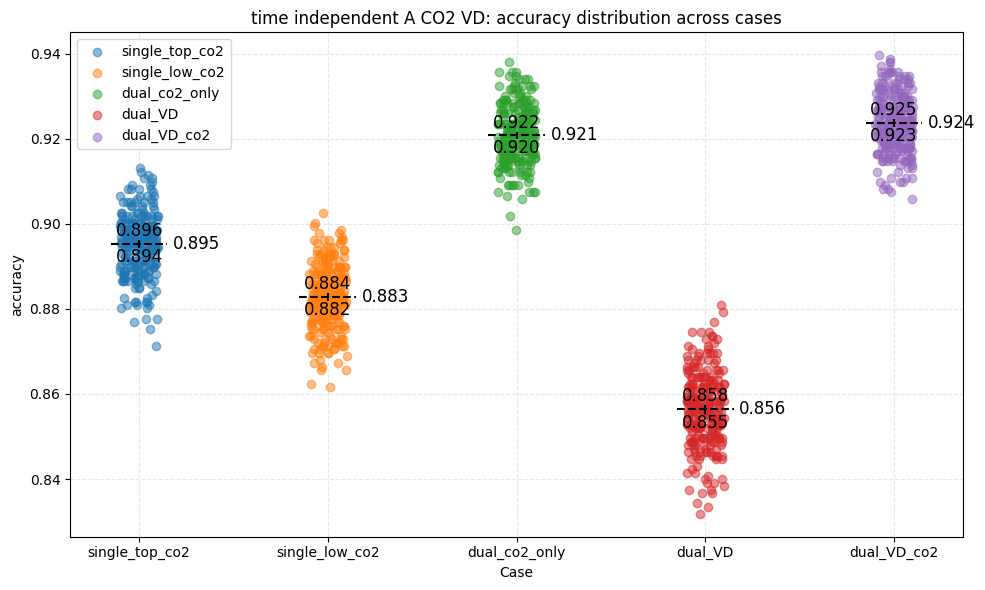

In [14]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

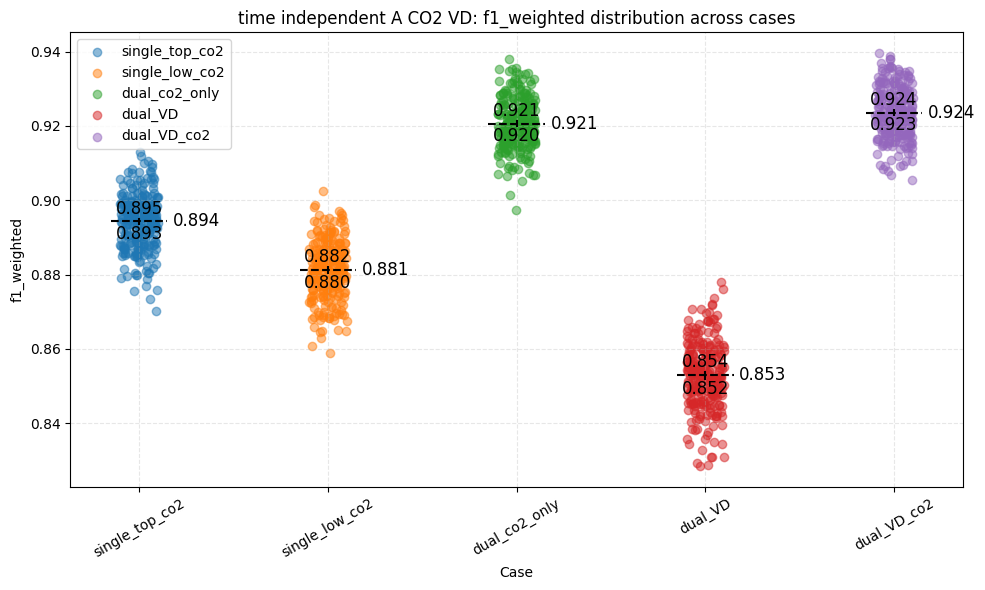

In [15]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order, rotation=30)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

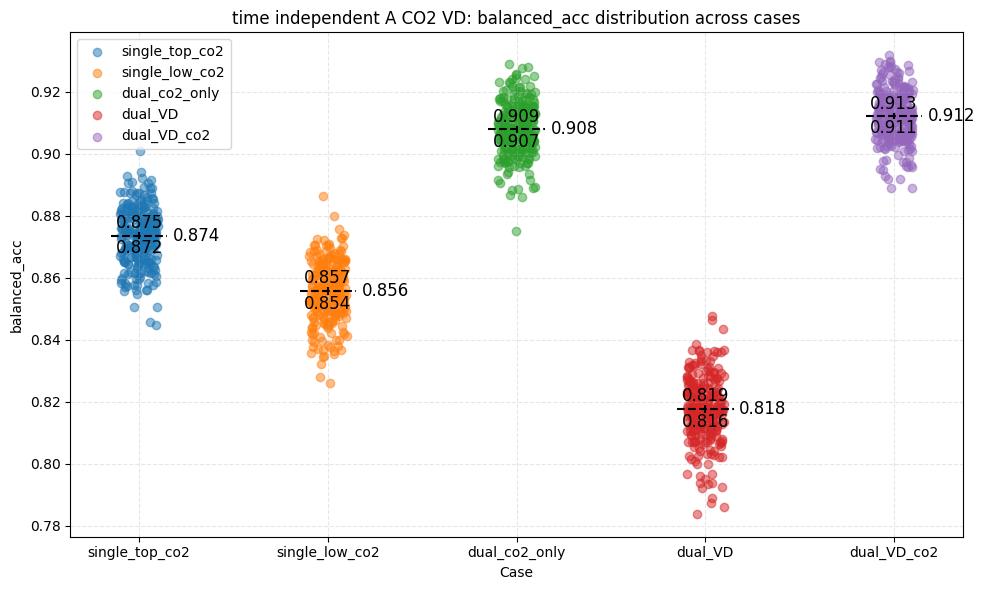

In [16]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

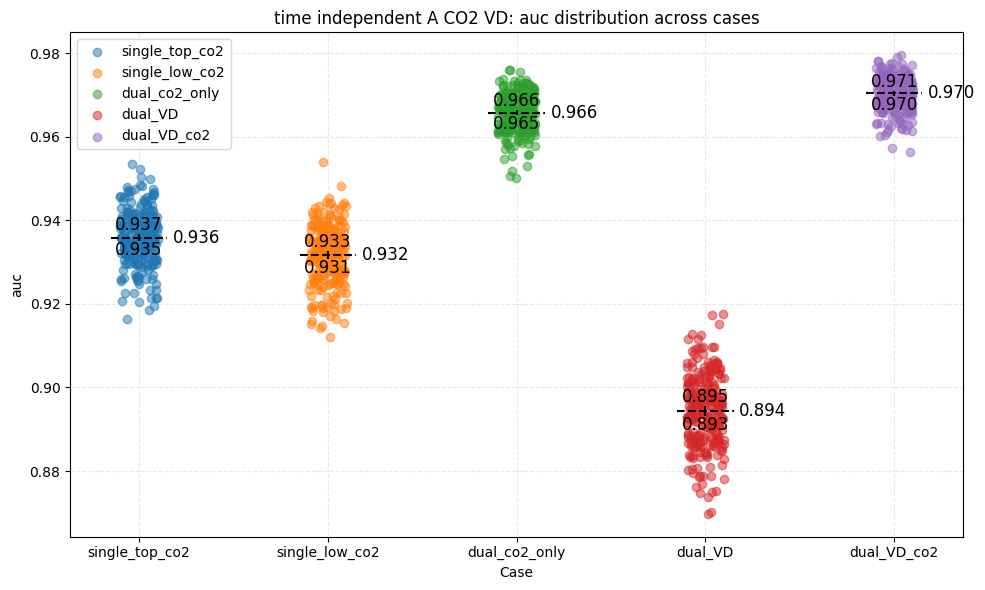

In [17]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent A CO2 VD

=== Normality test (D’Agostino and Pearson) for accuracy ===
single_top_co2           :	p = 0.2018	→	OK normal
single_low_co2           :	p = 0.5587	→	OK normal
dual_co2_only            :	p = 0.8547	→	OK normal
dual_VD                  :	p = 0.8530	→	OK normal
dual_VD_co2              :	p = 0.2566	→	OK normal

=== Normality test (Shapiro-Wilk) for accuracy ===
single_top_co2           :	p = 0.0847	→	OK normal
single_low_co2           :	p = 0.7152	→	OK normal
dual_co2_only            :	p = 0.1475	→	OK normal
dual_VD                  :	p = 0.7428	→	OK normal
dual_VD_co2              :	p = 0.2117	→	OK normal

=== Normality test (Anderson-Darling) for accuracy ===
single_top_co2           :	A² = 0.9679,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 0.2952,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.8340,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 0.3332,	5% critical = 0.7750	→	OK normal
dual_VD_co

In [19]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent A CO2 VD

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
single_top_co2           :	p = 0.2176	→	OK normal
single_low_co2           :	p = 0.5960	→	OK normal
dual_co2_only            :	p = 0.7348	→	OK normal
dual_VD                  :	p = 0.6573	→	OK normal
dual_VD_co2              :	p = 0.2910	→	OK normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
single_top_co2           :	p = 0.1501	→	OK normal
single_low_co2           :	p = 0.9008	→	OK normal
dual_co2_only            :	p = 0.2376	→	OK normal
dual_VD                  :	p = 0.6665	→	OK normal
dual_VD_co2              :	p = 0.3242	→	OK normal

=== Normality test (Anderson-Darling) for f1_weighted ===
single_top_co2           :	A² = 0.8316,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 0.1900,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.6426,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.2255,	5% critical = 0.7750	→	OK normal
du

In [20]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent A CO2 VD

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
single_top_co2           :	p = 0.2716	→	OK normal
single_low_co2           :	p = 0.2105	→	OK normal
dual_co2_only            :	p = 0.1451	→	OK normal
dual_VD                  :	p = 0.0544	→	OK normal
dual_VD_co2              :	p = 0.6721	→	OK normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
single_top_co2           :	p = 0.3840	→	OK normal
single_low_co2           :	p = 0.1935	→	OK normal
dual_co2_only            :	p = 0.1901	→	OK normal
dual_VD                  :	p = 0.1003	→	OK normal
dual_VD_co2              :	p = 0.2683	→	OK normal

=== Normality test (Anderson-Darling) for balanced_acc ===
single_top_co2           :	A² = 0.5253,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 0.6120,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.4206,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.5256,	5% critical = 0.7750	→	OK normal


In [21]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent A CO2 VD

=== Normality test (D’Agostino and Pearson) for auc ===
single_top_co2           :	p = 0.4545	→	OK normal
single_low_co2           :	p = 0.2502	→	OK normal
dual_co2_only            :	p = 0.0009	→	not normal
dual_VD                  :	p = 0.8943	→	OK normal
dual_VD_co2              :	p = 0.0026	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
single_top_co2           :	p = 0.6377	→	OK normal
single_low_co2           :	p = 0.0728	→	OK normal
dual_co2_only            :	p = 0.0032	→	not normal
dual_VD                  :	p = 0.8996	→	OK normal
dual_VD_co2              :	p = 0.0027	→	not normal

=== Normality test (Anderson-Darling) for auc ===
single_top_co2           :	A² = 0.3200,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 0.7900,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 0.7729,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.2107,	5% critical = 0.7750	→	OK normal
dual_VD_co2           

### ANOVA

In [22]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent A CO2 VD

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2           F  p-unc      np2
  case      4 621.184111 3206.047029    0.0 0.917303

Effect size (partial η², np2) = 0.9173 → large effect

=== Games-Howell post-hoc test for accuracy ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.856402 0.923717 -0.067315 0.000707 -95.231100 469.201073 3.019807e-13 -8.504894
       dual_VD  dual_co2_only 0.856402 0.920895 -0.064492 0.000701 -92.024867 464.314586 7.904788e-14 -8.218552
       dual_VD single_low_co2 0.856402 0.882819 -0.026417 0.000741 -35.627630 489.219143 3.539391e-13 -3.181831
       dual_VD single_top_co2 0.856402 0.895244 -0.038842 0.000727 -53.461464 482.190351 0.000000e+00 -4.774534
   dual_VD_co2  dual_co2_only 0.923717 0.920895  0.002822 0.000606   4.656345 497.733345 4.056911e-05  0.415849
   dual_VD_co2 single_low_co2 0.923717 0.882819  0.040898 

In [23]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent A CO2 VD

=== Welch ANOVA for f1_weighted ===
Source  ddof1      ddof2           F  p-unc      np2
  case      4 620.878021 3337.929266    0.0 0.920909

Effect size (partial η², np2) = 0.9209 → large effect

=== Games-Howell post-hoc test for f1_weighted ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.852840 0.923577 -0.070737 0.000726 -97.373109 461.938507 3.674838e-14 -8.696193
       dual_VD  dual_co2_only 0.852840 0.920654 -0.067815 0.000722 -93.970538 457.768792 2.282619e-13 -8.392316
       dual_VD single_low_co2 0.852840 0.881218 -0.028379 0.000767 -37.023027 487.161910 1.552092e-13 -3.306451
       dual_VD single_top_co2 0.852840 0.894296 -0.041457 0.000751 -55.214979 479.267523 0.000000e+00 -4.931136
   dual_VD_co2  dual_co2_only 0.923577 0.920654  0.002922 0.000611   4.782593 497.827908 2.247569e-05  0.427124
   dual_VD_co2 single_low_co2 0.923577 0.881218  0.0

In [24]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent A CO2 VD

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2           F  p-unc      np2
  case      4 621.214862 4029.206667    0.0 0.932363

Effect size (partial η², np2) = 0.9324 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval    hedges
       dual_VD    dual_VD_co2 0.817599 0.912125 -0.094526 0.000872 -108.459288 468.604291 1.364464e-13 -9.686276
       dual_VD  dual_co2_only 0.817599 0.907818 -0.090219 0.000874 -103.215726 470.194526 2.894351e-13 -9.217985
       dual_VD single_low_co2 0.817599 0.855663 -0.038064 0.000926  -41.105637 492.292989 0.000000e+00 -3.671060
       dual_VD single_top_co2 0.817599 0.873503 -0.055904 0.000908  -61.567412 486.751878 2.424727e-13 -5.498459
   dual_VD_co2  dual_co2_only 0.912125 0.907818  0.004307 0.000757    5.685814 497.970065 2.213256e-07  0.507788
   dual_VD_co2 single_low_co2 0.912125 0.855

In [25]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent A CO2 VD

=== Welch ANOVA for auc ===
Source  ddof1      ddof2           F  p-unc      np2
  case      4 610.457767 5351.939161    0.0 0.947245

Effect size (partial η², np2) = 0.9472 → large effect

=== Games-Howell post-hoc test for auc ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.894344 0.970347 -0.076003 0.000614 -123.757092 349.795815 1.140199e-13 -11.052492
       dual_VD  dual_co2_only 0.894344 0.965744 -0.071400 0.000627 -113.851684 371.620684 8.093526e-14 -10.167860
       dual_VD single_low_co2 0.894344 0.931682 -0.037338 0.000718  -51.979239 477.595236 1.020295e-13  -4.642159
       dual_VD single_top_co2 0.894344 0.935845 -0.041501 0.000698  -59.462790 462.218885 2.260414e-13  -5.310500
   dual_VD_co2  dual_co2_only 0.970347 0.965744  0.004603 0.000384   11.972334 492.130928 1.685319e-13   1.069225
   dual_VD_co2 single_low_co2 0.970347 0.931682  0.03866

## Time series - A

In [26]:
model = "time series A CO2 VD"
single_top_co2 = pd.read_csv("../../analysis_sensor_position/_timeseries_results_raw/case_LabEEE_A_top_state_timeseries_co2.csv")
single_low_co2 = pd.read_csv("../../analysis_sensor_position/_timeseries_results_raw/case_LabEEE_A_low_state_timeseries_co2.csv")
dual_co2_only = pd.read_csv("../_timeseries_results_raw/case_LabEEE_A_state_timeseries_co2only.csv")
dual_VD = pd.read_csv("../_timeseries_results_raw/case_LabEEE_A_state_timeseries_VD.csv")
dual_VD_co2 = pd.read_csv("../_timeseries_results_raw/case_LabEEE_A_state_timeseries_VDco2.csv")

In [27]:
single_top_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.865322,0.059501,0.718367,0.820612,0.891429,0.912653,0.931429
f1,250.0,0.869947,0.048437,0.756528,0.831035,0.890173,0.908551,0.927959
balanced_acc,250.0,0.871537,0.055014,0.734942,0.830243,0.895931,0.914701,0.933307
auc,250.0,0.949830,0.010701,0.886396,0.945062,0.951463,0.955672,0.969426
feature_importance.A_top_CO2_scaled,250.0,-0.036471,0.036542,-0.137143,-0.064531,-0.022408,-0.008878,0.036490
feature_importance.A_top_CO2_fd1_scaled,250.0,0.093212,0.046755,0.001878,0.059510,0.088735,0.124020,0.231347
feature_importance.A_top_CO2_fd2_scaled,250.0,0.093441,0.044005,0.011265,0.060878,0.090327,0.119633,0.223837
feature_importance.A_top_CO2_fd3_scaled,250.0,0.087864,0.048504,-0.004408,0.050082,0.080082,0.117653,0.233388


In [28]:
single_low_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.907641,0.004902,0.891429,0.904490,0.907755,0.911020,0.920816
f1,250.0,0.903992,0.004752,0.886809,0.901211,0.904110,0.907095,0.916162
balanced_acc,250.0,0.910156,0.004657,0.893638,0.907445,0.910381,0.913191,0.922057
auc,250.0,0.951357,0.005943,0.931888,0.947527,0.951435,0.956161,0.962341
feature_importance.A_low_CO2_scaled,250.0,0.001704,0.003298,-0.008735,-0.000327,0.001551,0.003755,0.015592
feature_importance.A_low_CO2_fd1_scaled,250.0,0.086349,0.035051,0.009959,0.061837,0.083469,0.102102,0.186041
feature_importance.A_low_CO2_fd2_scaled,250.0,0.113736,0.038910,0.032082,0.083551,0.110531,0.141286,0.216082
feature_importance.A_low_CO2_fd3_scaled,250.0,0.078857,0.040270,0.006612,0.049286,0.072857,0.103122,0.189551


In [29]:
dual_co2_only.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.909610,0.041370,0.685714,0.909592,0.922449,0.930612,0.948571
f1,250.0,0.907587,0.034414,0.735758,0.904593,0.918077,0.926629,0.944978
balanced_acc,250.0,0.912199,0.038330,0.704639,0.911012,0.923887,0.932008,0.949216
auc,250.0,0.957786,0.009196,0.906114,0.953584,0.958488,0.963527,0.978343
feature_importance.A_low_CO2_scaled,250.0,0.036798,0.043397,-0.039429,0.004837,0.020122,0.062082,0.173388
feature_importance.A_low_CO2_fd1_scaled,250.0,0.022589,0.020799,-0.002694,0.009796,0.015755,0.027878,0.116082
feature_importance.A_low_CO2_fd2_scaled,250.0,0.020593,0.019357,-0.005061,0.007347,0.013959,0.029082,0.115020
feature_importance.A_low_CO2_fd3_scaled,250.0,0.011276,0.016666,-0.011184,0.001878,0.007143,0.012388,0.090367


In [30]:
dual_VD.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.663363,0.008592,0.634126,0.659557,0.662838,0.667555,0.748154
f1,250.0,0.717451,0.007078,0.690707,0.713224,0.717033,0.721918,0.768651
balanced_acc,250.0,0.680970,0.008469,0.650953,0.676821,0.680360,0.685298,0.758667
auc,250.0,0.703410,0.075963,0.480412,0.653756,0.706521,0.761443,0.845282
feature_importance.A_CO2_vd_scaled,250.0,0.118589,0.047457,-0.098031,0.092986,0.124938,0.154409,0.194176
feature_importance.A_CO2_vd_fd1_scaled,250.0,0.012102,0.005626,0.001313,0.008244,0.011075,0.014746,0.043970
feature_importance.A_CO2_vd_fd2_scaled,250.0,0.021551,0.007477,0.006809,0.016509,0.021165,0.025615,0.061198
feature_importance.A_CO2_vd_fd3_scaled,250.0,0.022918,0.010293,0.000492,0.015505,0.022806,0.028938,0.065217


In [31]:
dual_VD_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.848549,0.091377,0.669374,0.777417,0.897644,0.918765,0.941511
f1,250.0,0.856394,0.071067,0.724068,0.797130,0.892366,0.911826,0.937608
balanced_acc,250.0,0.854867,0.083917,0.690284,0.790503,0.899406,0.918569,0.942725
auc,250.0,0.935320,0.039961,0.660768,0.937403,0.947640,0.953947,0.969712
feature_importance.A_CO2_vd_scaled,250.0,0.006161,0.043245,-0.108367,-0.014074,-0.000406,0.032595,0.132981
feature_importance.A_CO2_vd_fd1_scaled,250.0,0.002719,0.009374,-0.023314,-0.001787,0.001300,0.005361,0.046548
feature_importance.A_CO2_vd_fd2_scaled,250.0,0.003596,0.009341,-0.026970,-0.001543,0.002153,0.007656,0.052965
feature_importance.A_CO2_vd_fd3_scaled,250.0,0.007918,0.011715,-0.030463,0.000711,0.005849,0.014419,0.052884


In [32]:
single_top_co2['case'] = 'single_top_co2'
single_low_co2['case'] = 'single_low_co2'
dual_co2_only['case'] = 'dual_co2_only'
dual_VD['case'] = 'dual_VD'
dual_VD_co2['case'] = 'dual_VD_co2'

metrics = ["case", "accuracy", "f1", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        single_top_co2[metrics],
        single_low_co2[metrics],
        dual_co2_only[metrics],
        dual_VD[metrics],
        dual_VD_co2[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1250 non-null   object 
 1   accuracy      1250 non-null   float64
 2   f1            1250 non-null   float64
 3   balanced_acc  1250 non-null   float64
 4   auc           1250 non-null   float64
dtypes: float64(4), object(1)
memory usage: 49.0+ KB


In [33]:
case_order = ['single_top_co2', 'single_low_co2', 'dual_co2_only', 'dual_VD', 'dual_VD_co2']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,single_top_co2,single_top_co2,single_top_co2,single_top_co2,single_top_co2
accuracy,0.923265,0.804898,0.915102,0.797551,0.796735
f1,0.918966,0.817974,0.911565,0.814093,0.812923
balanced_acc,0.924712,0.815373,0.917518,0.809319,0.808307
auc,0.966133,0.939166,0.959952,0.951789,0.94937
x,0,0,0,0,0
x_jitter,0.034143,0.031912,-0.027966,0.018201,-0.00998


### plot

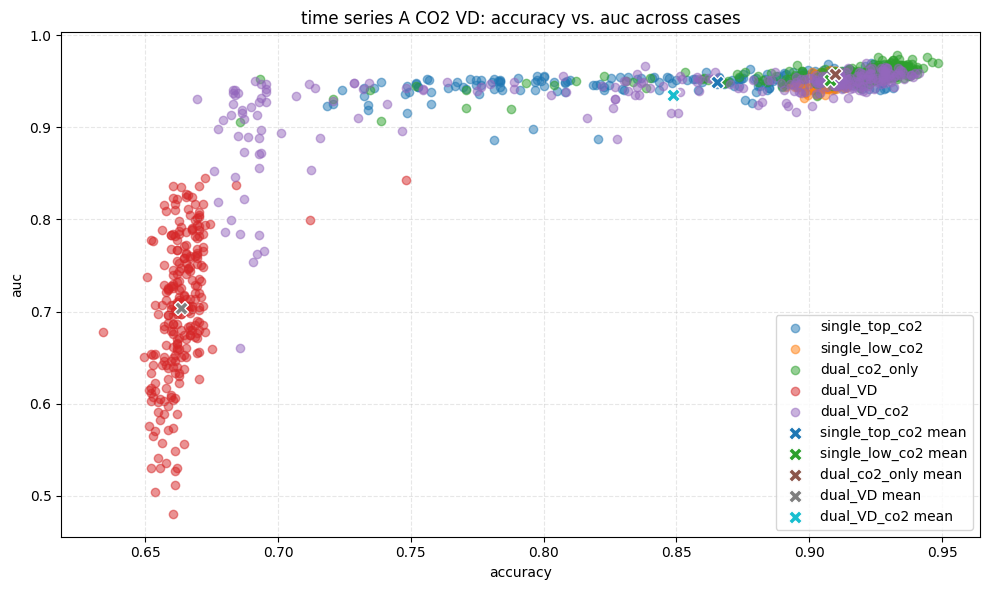

In [34]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

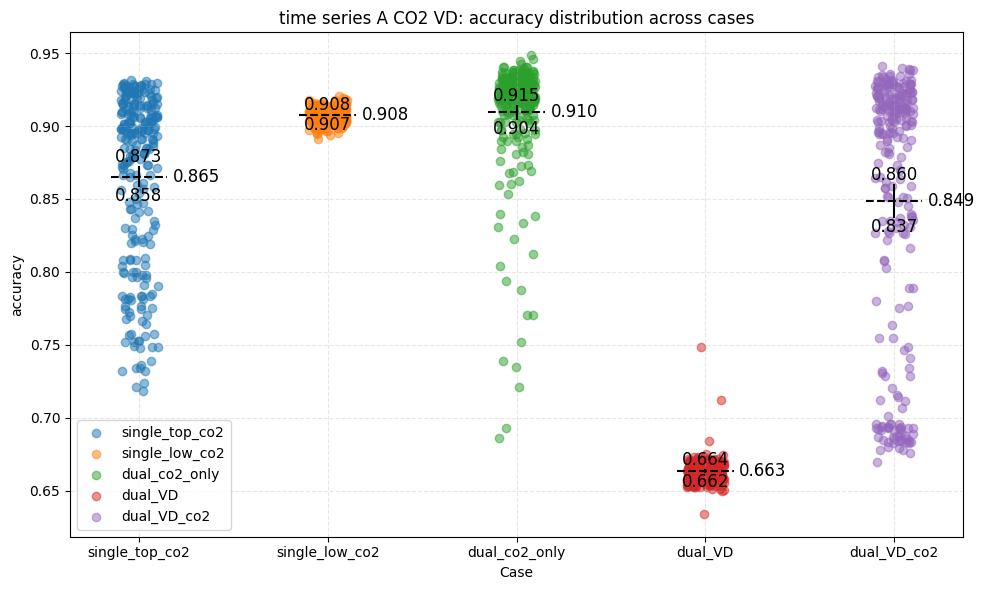

In [35]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

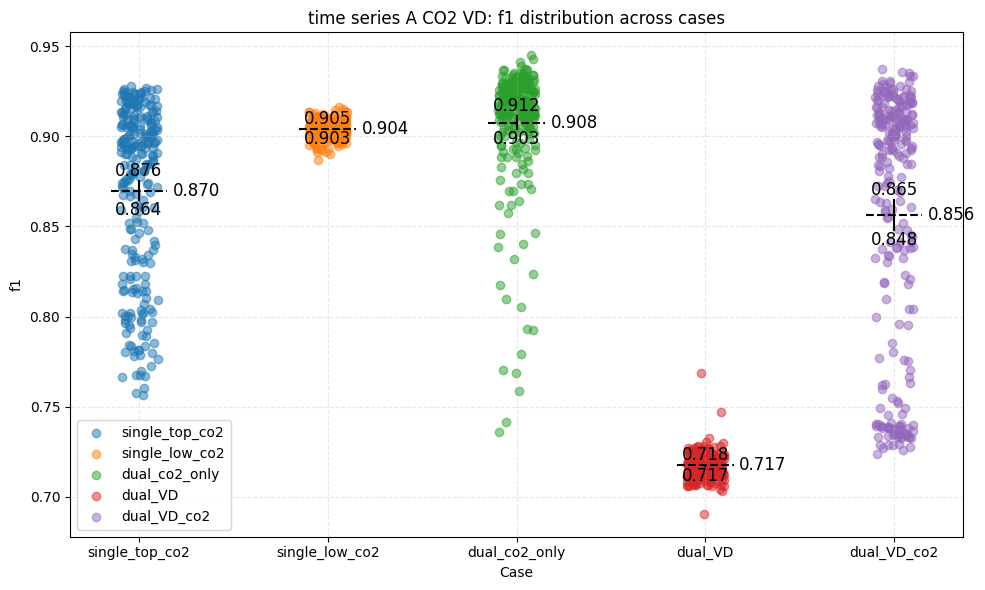

In [36]:
# plot f1 score
metric = "f1"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

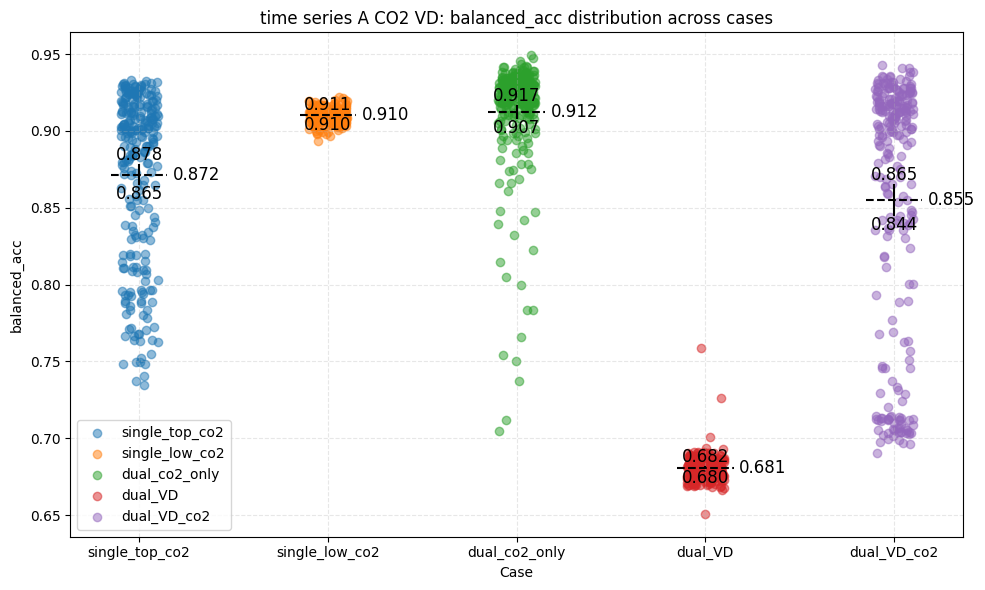

In [37]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

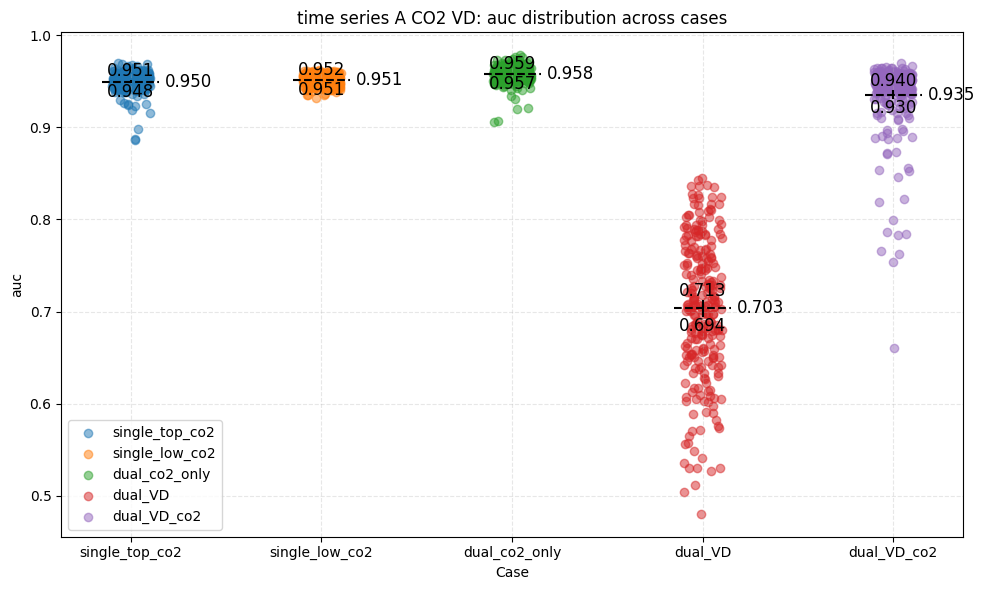

In [38]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time series A CO2 VD

=== Normality test (D’Agostino and Pearson) for accuracy ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0215	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0224	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
single_top_co2           :	A² = 13.0412,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 1.0712,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 30.1124,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 8.3112,	5% critical = 0.7750	→	not normal
d

In [40]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1',
    group_order=case_order
)

time series A CO2 VD

=== Normality test (D’Agostino and Pearson) for f1 ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0119	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for f1 ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0747	→	OK normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for f1 ===
single_top_co2           :	A² = 11.3424,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 0.5404,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 24.4498,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 1.7455,	5% critical = 0.7750	→	not normal
dual_VD_co2          

In [41]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time series A CO2 VD

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0132	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0710	→	OK normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for balanced_acc ===
single_top_co2           :	A² = 13.0980,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 0.6041,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 28.9687,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 5.6726,	5% critical = 0.7750	→	no

In [42]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time series A CO2 VD

=== Normality test (D’Agostino and Pearson) for auc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0133	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0312	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0003	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0030	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
single_top_co2           :	A² = 6.7986,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 1.1984,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 4.3967,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 0.7831,	5% critical = 0.7750	→	not normal
dual_VD_co2       

### ANOVA

In [43]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time series A CO2 VD

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2            F  p-unc      np2
  case      4 552.156577 38114.564823    0.0 0.751797

Effect size (partial η², np2) = 0.7518 → large effect

=== Games-Howell post-hoc test for accuracy ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.663363 0.848549 -0.185186 0.005805  -31.902671 253.403048 0.000000e+00  -2.849162
       dual_VD  dual_co2_only 0.663363 0.909610 -0.246246 0.002672  -92.147146 270.442903 5.295764e-14  -8.229473
       dual_VD single_low_co2 0.663363 0.907641 -0.244277 0.000626 -390.429598 395.576124 3.336220e-13 -34.868466
       dual_VD single_top_co2 0.663363 0.865322 -0.201959 0.003802  -53.115794 259.380554 0.000000e+00  -4.743663
   dual_VD_co2  dual_co2_only 0.848549 0.909610 -0.061061 0.006344   -9.625070 346.960776 1.598721e-14  -0.859595
   dual_VD_co2 single_low_co2 0.848549 0.907641 -

In [44]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1'
)

time series A CO2 VD

=== Welch ANOVA for f1 ===
Source  ddof1     ddof2            F  p-unc      np2
  case      4 561.65464 30029.265397    0.0 0.737647

Effect size (partial η², np2) = 0.7376 → large effect

=== Games-Howell post-hoc test for f1 ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.717451 0.856394 -0.138943 0.004517  -30.760674 253.939795 0.000000e+00  -2.747173
       dual_VD  dual_co2_only 0.717451 0.907587 -0.190136 0.002222  -85.566264 270.029963 2.320366e-14  -7.641748
       dual_VD single_low_co2 0.717451 0.903992 -0.186541 0.000539 -345.969316 435.533104 3.356204e-13 -30.897810
       dual_VD single_top_co2 0.717451 0.869947 -0.152496 0.003096  -49.256816 259.630226 0.000000e+00  -4.399025
   dual_VD_co2  dual_co2_only 0.856394 0.907587 -0.051193 0.004994  -10.251144 359.692479 1.629807e-13  -0.915509
   dual_VD_co2 single_low_co2 0.856394 0.903992 -0.047598 0.004

In [45]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time series A CO2 VD

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2            F  p-unc      np2
  case      4 550.337534 35150.537143    0.0 0.758898

Effect size (partial η², np2) = 0.7589 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.680970 0.854867 -0.173897 0.005334  -32.599766 254.071439 0.000000e+00  -2.911418
       dual_VD  dual_co2_only 0.680970 0.912199 -0.231229 0.002483  -93.136380 273.252230 0.000000e+00  -8.317819
       dual_VD single_low_co2 0.680970 0.910156 -0.229186 0.000611 -374.944131 386.973801 5.040413e-14 -33.485491
       dual_VD single_top_co2 0.680970 0.871537 -0.190567 0.003520  -54.133090 260.794764 0.000000e+00  -4.834515
   dual_VD_co2  dual_co2_only 0.854867 0.912199 -0.057332 0.005835   -9.825824 348.567047 0.000000e+00  -0.877524
   dual_VD_co2 single_low_co2 0.854867 0.

In [46]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time series A CO2 VD

=== Welch ANOVA for auc ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 583.700181 705.220776 7.325508e-222 0.864617

Effect size (partial η², np2) = 0.8646 → large effect

=== Games-Howell post-hoc test for auc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.703410 0.935320 -0.231911 0.005429 -42.720479 377.010299 7.505108e-14 -3.815278
       dual_VD  dual_co2_only 0.703410 0.957786 -0.254376 0.004839 -52.563330 256.296757 0.000000e+00 -4.694323
       dual_VD single_low_co2 0.703410 0.951357 -0.247947 0.004819 -51.451687 252.047637 0.000000e+00 -4.595045
       dual_VD single_top_co2 0.703410 0.949830 -0.246420 0.004852 -50.789609 258.879448 0.000000e+00 -4.535916
   dual_VD_co2  dual_co2_only 0.935320 0.957786 -0.022466 0.002593  -8.662556 275.299306 1.088019e-14 -0.773635
   dual_VD_co2 single_low_co2 0.935320 0.951357 -0.016036 0.0

## Time independent - B

In [47]:
model = "time independent B CO2 VD"
single_top_co2 = pd.read_csv("../../analysis_sensor_position/_timeindep_results_raw/case_LabEEE_B_top_state_timeindep_co2.csv")
single_low_co2 = pd.read_csv("../../analysis_sensor_position/_timeindep_results_raw/case_LabEEE_B_low_state_timeindep_co2.csv")
dual_co2_only = pd.read_csv("../_timeindep_results_raw/case_LabEEE_B_state_timeindep_co2only.csv")
dual_VD = pd.read_csv("../_timeindep_results_raw/case_LabEEE_B_state_timeindep_VD.csv")
dual_VD_co2 = pd.read_csv("../_timeindep_results_raw/case_LabEEE_B_state_timeindep_VDco2.csv")

In [48]:
single_top_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.894359,0.007993,0.875302,0.889179,0.894610,0.900040,0.920354
f1_weighted,250.0,0.893203,0.008169,0.873504,0.888133,0.893370,0.898983,0.919777
balanced_acc,250.0,0.870927,0.009837,0.847640,0.863943,0.871251,0.877267,0.902186
auc,250.0,0.930092,0.007549,0.908322,0.925435,0.929842,0.935354,0.950995
model_weights.random_forest,250.0,0.847306,0.317120,-0.005195,0.621897,0.850652,1.084740,1.558276
model_weights.bagging_svc,250.0,-0.164088,0.166500,-0.679100,-0.281183,-0.169114,-0.054647,0.255460
model_weights.bagging_knn,250.0,0.342371,0.183857,-0.369002,0.227273,0.350974,0.477903,0.843112
model_weights.gradient_boosting,250.0,2.701865,0.269014,1.980424,2.524408,2.690069,2.880501,3.493333


In [49]:
single_low_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.867276,0.007898,0.843121,0.862430,0.867257,0.872888,0.893001
f1_weighted,250.0,0.865553,0.008061,0.841792,0.860503,0.865550,0.871499,0.891958
balanced_acc,250.0,0.838609,0.009571,0.811109,0.832665,0.838660,0.844776,0.867920
auc,250.0,0.919211,0.006911,0.899532,0.914755,0.919381,0.924039,0.942130
model_weights.random_forest,250.0,1.526073,0.299694,0.583827,1.329693,1.555126,1.728263,2.396320
model_weights.bagging_svc,250.0,-0.334126,0.136194,-0.745948,-0.421946,-0.338444,-0.238919,0.097376
model_weights.bagging_knn,250.0,0.078181,0.192078,-0.483476,-0.045201,0.096479,0.212523,0.525651
model_weights.gradient_boosting,250.0,3.294160,0.260772,2.629831,3.117534,3.291086,3.458932,4.084509


In [50]:
dual_co2_only.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.918764,0.006840,0.900241,0.913918,0.919549,0.922767,0.939662
f1_weighted,250.0,0.918552,0.006883,0.899764,0.913799,0.918984,0.922950,0.939323
balanced_acc,250.0,0.905794,0.008424,0.881128,0.901011,0.906128,0.911102,0.928064
auc,250.0,0.965106,0.005099,0.950085,0.962222,0.964946,0.968486,0.976368
model_weights.random_forest,250.0,0.658440,0.346212,-0.416702,0.398241,0.688589,0.926114,1.595817
model_weights.bagging_svc,250.0,0.134783,0.271487,-0.689859,-0.048101,0.112158,0.325340,1.025807
model_weights.bagging_knn,250.0,-0.842334,0.212293,-1.427629,-0.990843,-0.823721,-0.692524,-0.282725
model_weights.gradient_boosting,250.0,3.581330,0.280094,2.635443,3.416421,3.575208,3.773550,4.325085


In [51]:
dual_VD.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.818993,0.009793,0.790829,0.813355,0.818986,0.826227,0.844730
f1_weighted,250.0,0.811616,0.010433,0.780159,0.805365,0.811900,0.819274,0.839415
balanced_acc,250.0,0.765124,0.011667,0.729713,0.756869,0.765819,0.773066,0.796403
auc,250.0,0.860408,0.009706,0.831390,0.853108,0.861385,0.866668,0.885577
model_weights.random_forest,250.0,1.385274,0.294760,0.448587,1.155021,1.405865,1.598388,2.226837
model_weights.bagging_svc,250.0,-0.298947,0.142325,-0.710908,-0.389224,-0.297703,-0.203652,0.221910
model_weights.bagging_knn,250.0,0.907670,0.249135,0.217049,0.726773,0.909973,1.067724,1.942169
model_weights.gradient_boosting,250.0,2.192685,0.271553,1.438824,2.003145,2.176979,2.370978,2.953702


In [52]:
dual_VD_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.919379,0.007004,0.901046,0.914722,0.919549,0.923572,0.940467
f1_weighted,250.0,0.919110,0.007051,0.900466,0.914629,0.918934,0.923653,0.940467
balanced_acc,250.0,0.905804,0.008541,0.881065,0.900117,0.905867,0.911580,0.931533
auc,250.0,0.969153,0.004440,0.956511,0.966386,0.969263,0.972371,0.979678
model_weights.random_forest,250.0,2.633112,0.387810,1.569553,2.394246,2.635426,2.889495,3.671603
model_weights.bagging_svc,250.0,-0.183406,0.244998,-0.928387,-0.356553,-0.167076,-0.022179,0.436278
model_weights.bagging_knn,250.0,-0.764728,0.170431,-1.236578,-0.870389,-0.756672,-0.661672,-0.314465
model_weights.gradient_boosting,250.0,2.800395,0.306571,1.803247,2.592735,2.817292,2.980619,3.584758


In [53]:
single_top_co2['case'] = 'single_top_co2'
single_low_co2['case'] = 'single_low_co2'
dual_co2_only['case'] = 'dual_co2_only'
dual_VD['case'] = 'dual_VD'
dual_VD_co2['case'] = 'dual_VD_co2'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        single_top_co2[metrics],
        single_low_co2[metrics],
        dual_co2_only[metrics],
        dual_VD[metrics],
        dual_VD_co2[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1250 non-null   object 
 1   accuracy      1250 non-null   float64
 2   f1_weighted   1250 non-null   float64
 3   balanced_acc  1250 non-null   float64
 4   auc           1250 non-null   float64
dtypes: float64(4), object(1)
memory usage: 49.0+ KB


In [54]:
case_order = ['single_top_co2', 'single_low_co2', 'dual_co2_only', 'dual_VD', 'dual_VD_co2']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,single_top_co2,single_top_co2,single_top_co2,single_top_co2,single_top_co2
accuracy,0.893805,0.887369,0.89461,0.891392,0.900241
f1_weighted,0.892753,0.885173,0.893011,0.890176,0.900111
balanced_acc,0.873156,0.858468,0.868676,0.871621,0.884881
auc,0.931301,0.926921,0.926684,0.931327,0.93432
x,0,0,0,0,0
x_jitter,0.073906,0.035285,-0.043252,0.012934,0.027388


### plot

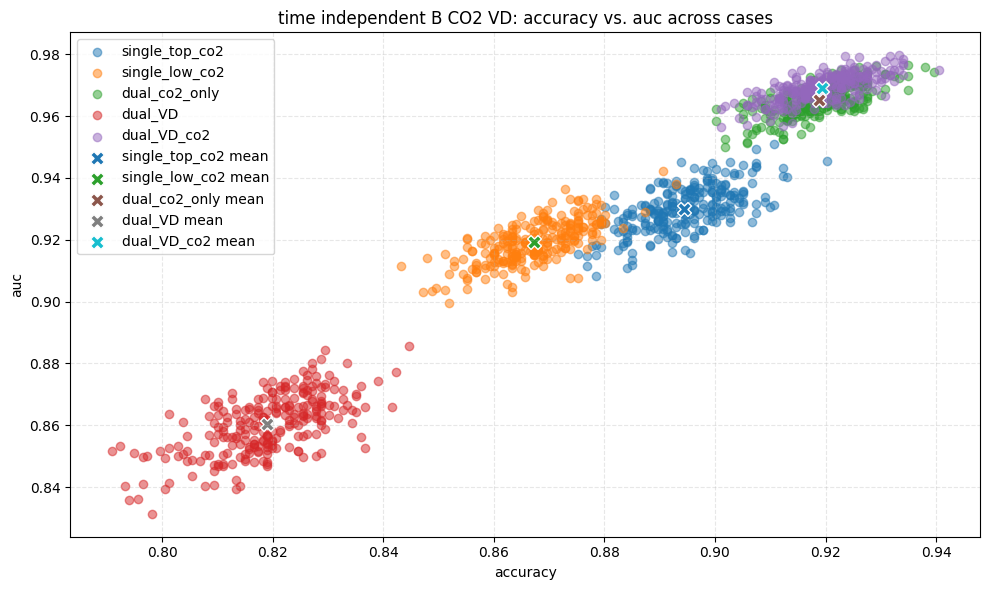

In [55]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

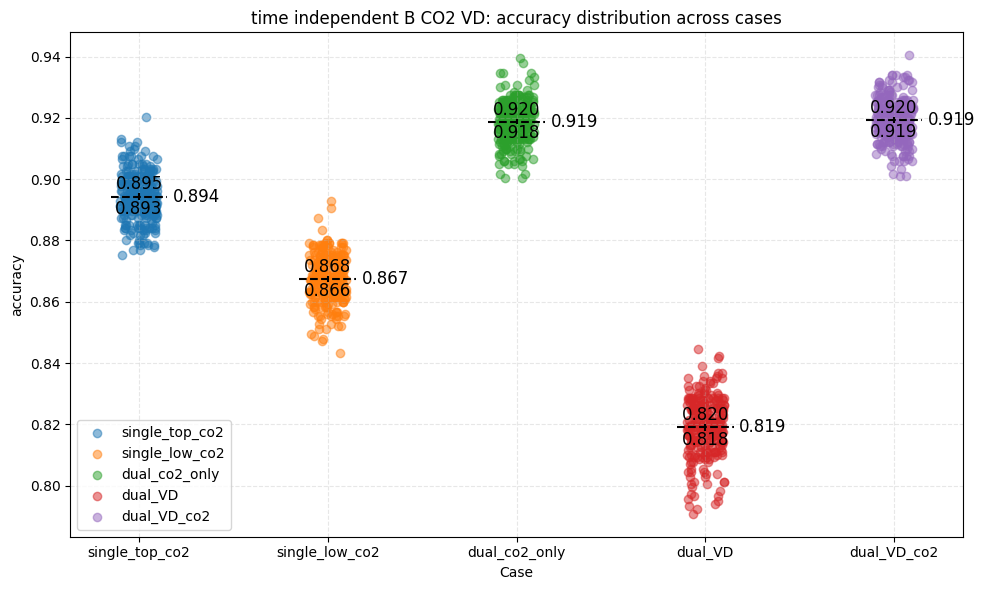

In [56]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

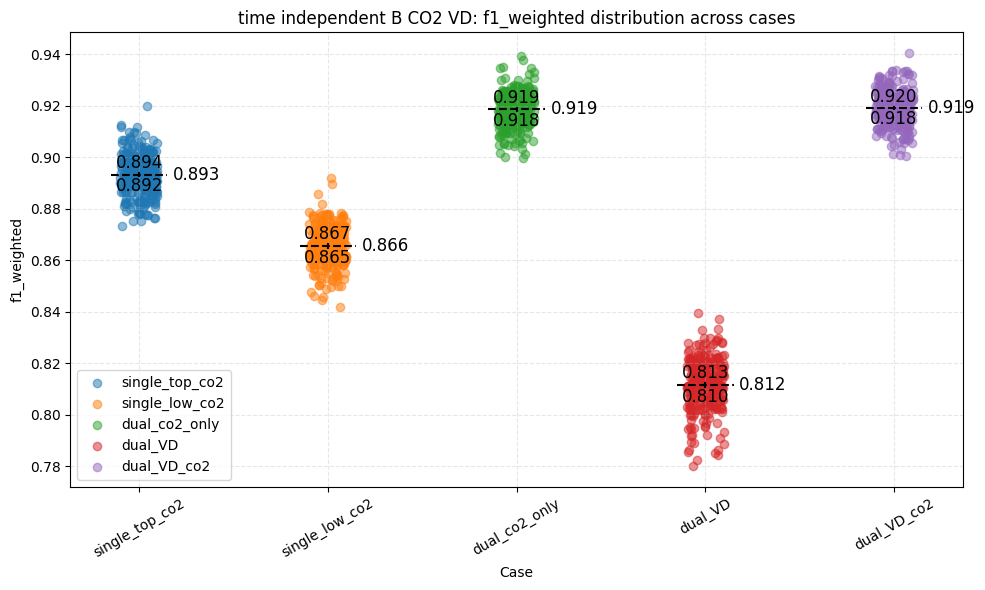

In [57]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order, rotation=30)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

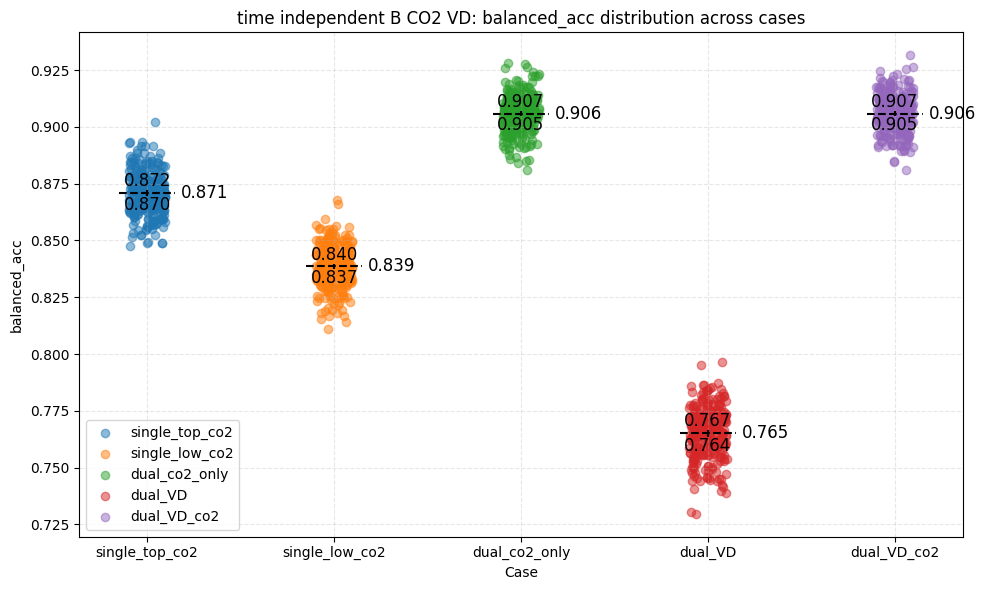

In [58]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

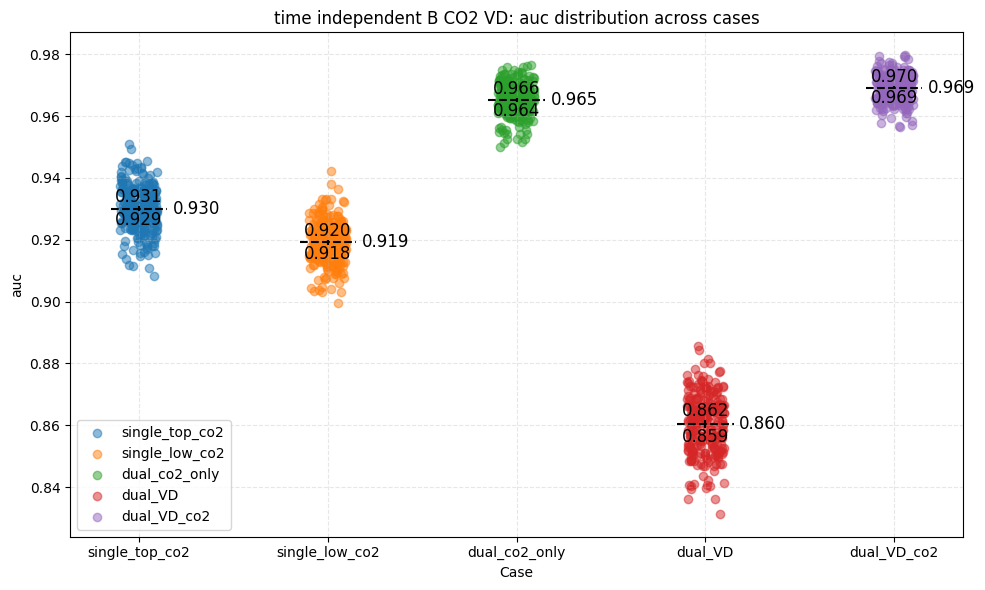

In [59]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent B CO2 VD

=== Normality test (D’Agostino and Pearson) for accuracy ===
single_top_co2           :	p = 0.8394	→	OK normal
single_low_co2           :	p = 0.6308	→	OK normal
dual_co2_only            :	p = 0.5053	→	OK normal
dual_VD                  :	p = 0.0321	→	not normal
dual_VD_co2              :	p = 0.9857	→	OK normal

=== Normality test (Shapiro-Wilk) for accuracy ===
single_top_co2           :	p = 0.5651	→	OK normal
single_low_co2           :	p = 0.1599	→	OK normal
dual_co2_only            :	p = 0.1378	→	OK normal
dual_VD                  :	p = 0.0120	→	not normal
dual_VD_co2              :	p = 0.7789	→	OK normal

=== Normality test (Anderson-Darling) for accuracy ===
single_top_co2           :	A² = 0.3025,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 0.5927,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.7542,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 1.0444,	5% critical = 0.7750	→	not normal
dual_VD_c

In [61]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent B CO2 VD

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
single_top_co2           :	p = 0.8198	→	OK normal
single_low_co2           :	p = 0.6150	→	OK normal
dual_co2_only            :	p = 0.5177	→	OK normal
dual_VD                  :	p = 0.0290	→	not normal
dual_VD_co2              :	p = 0.9867	→	OK normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
single_top_co2           :	p = 0.7991	→	OK normal
single_low_co2           :	p = 0.2634	→	OK normal
dual_co2_only            :	p = 0.2674	→	OK normal
dual_VD                  :	p = 0.0238	→	not normal
dual_VD_co2              :	p = 0.9086	→	OK normal

=== Normality test (Anderson-Darling) for f1_weighted ===
single_top_co2           :	A² = 0.1832,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 0.4259,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.5729,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.8499,	5% critical = 0.7750	→	not normal


In [62]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent B CO2 VD

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
single_top_co2           :	p = 0.7490	→	OK normal
single_low_co2           :	p = 0.6119	→	OK normal
dual_co2_only            :	p = 0.5097	→	OK normal
dual_VD                  :	p = 0.3406	→	OK normal
dual_VD_co2              :	p = 0.9538	→	OK normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
single_top_co2           :	p = 0.8486	→	OK normal
single_low_co2           :	p = 0.6936	→	OK normal
dual_co2_only            :	p = 0.5508	→	OK normal
dual_VD                  :	p = 0.4417	→	OK normal
dual_VD_co2              :	p = 0.9647	→	OK normal

=== Normality test (Anderson-Darling) for balanced_acc ===
single_top_co2           :	A² = 0.1395,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 0.2611,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.3944,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.3725,	5% critical = 0.7750	→	OK normal


In [63]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent B CO2 VD

=== Normality test (D’Agostino and Pearson) for auc ===
single_top_co2           :	p = 0.7946	→	OK normal
single_low_co2           :	p = 0.6944	→	OK normal
dual_co2_only            :	p = 0.1686	→	OK normal
dual_VD                  :	p = 0.4019	→	OK normal
dual_VD_co2              :	p = 0.3269	→	OK normal

=== Normality test (Shapiro-Wilk) for auc ===
single_top_co2           :	p = 0.9132	→	OK normal
single_low_co2           :	p = 0.9056	→	OK normal
dual_co2_only            :	p = 0.0391	→	not normal
dual_VD                  :	p = 0.2456	→	OK normal
dual_VD_co2              :	p = 0.3316	→	OK normal

=== Normality test (Anderson-Darling) for auc ===
single_top_co2           :	A² = 0.2304,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 0.1884,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.5943,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.6848,	5% critical = 0.7750	→	OK normal
dual_VD_co2              :

### ANOVA

In [64]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent B CO2 VD

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2          F  p-unc      np2
  case      4 620.397209 5984.42472    0.0 0.957137

Effect size (partial η², np2) = 0.9571 → large effect

=== Games-Howell post-hoc test for accuracy ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.818993 0.919379 -0.100386 0.000761 -131.835052 450.924736 2.134959e-13 -11.773918
       dual_VD  dual_co2_only 0.818993 0.918764 -0.099772 0.000755 -132.069160 445.244435 6.283862e-14 -11.794826
       dual_VD single_low_co2 0.818993 0.867276 -0.048283 0.000796  -60.681621 476.634338 5.884182e-15  -5.419351
       dual_VD single_top_co2 0.818993 0.894359 -0.075366 0.000799  -94.269687 478.799421 1.176836e-13  -8.419032
   dual_VD_co2  dual_co2_only 0.919379 0.918764  0.000615 0.000619    0.992697 497.719123 8.586199e-01   0.088656
   dual_VD_co2 single_low_co2 0.919379 0.867276 

In [65]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent B CO2 VD

=== Welch ANOVA for f1_weighted ===
Source  ddof1      ddof2           F  p-unc      np2
  case      4 619.806905 6217.698344    0.0 0.959957

Effect size (partial η², np2) = 0.9600 → large effect

=== Games-Howell post-hoc test for f1_weighted ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.811616 0.919110 -0.107494 0.000796 -134.971396 437.193957 5.850875e-14 -12.054018
       dual_VD  dual_co2_only 0.811616 0.918552 -0.106936 0.000791 -135.275557 431.209511 1.210143e-13 -12.081183
       dual_VD single_low_co2 0.811616 0.865553 -0.053937 0.000834  -64.681419 468.189123 0.000000e+00  -5.776565
       dual_VD single_top_co2 0.811616 0.893203 -0.081588 0.000838  -97.354517 470.892745 6.750156e-14  -8.694532
   dual_VD_co2  dual_co2_only 0.919110 0.918552  0.000558 0.000623    0.895352 497.709193 8.985843e-01   0.079962
   dual_VD_co2 single_low_co2 0.919110 0

In [66]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent B CO2 VD

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2           F  p-unc      np2
  case      4 620.651936 7911.153333    0.0 0.967151

Effect size (partial η², np2) = 0.9672 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.765124 0.905804 -0.140680 0.000914 -153.833330 456.334399 2.501332e-13 -13.738539
       dual_VD  dual_co2_only 0.765124 0.905794 -0.140670 0.000910 -154.560144 453.128596 2.218226e-13 -13.803449
       dual_VD single_low_co2 0.765124 0.838609 -0.073485 0.000954  -76.994004 479.668129 0.000000e+00  -6.876177
       dual_VD single_top_co2 0.765124 0.870927 -0.105803 0.000965 -109.621315 484.167663 1.830758e-13  -9.790055
   dual_VD_co2  dual_co2_only 0.905804 0.905794  0.000010 0.000759    0.012886 497.904743 1.000000e+00   0.001151
   dual_VD_co2 single_low_co2 0.905804

In [67]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent B CO2 VD

=== Welch ANOVA for auc ===
Source  ddof1      ddof2           F  p-unc      np2
  case      4 611.639082 8613.613389    0.0 0.969389

Effect size (partial η², np2) = 0.9694 → large effect

=== Games-Howell post-hoc test for auc ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.860408 0.969153 -0.108744 0.000675 -161.087116 348.837809 0.000000e+00 -14.386360
       dual_VD  dual_co2_only 0.860408 0.965106 -0.104698 0.000693 -150.982544 376.716297 4.607426e-14 -13.483941
       dual_VD single_low_co2 0.860408 0.919211 -0.058802 0.000754  -78.029326 449.841652 5.628831e-14  -6.968639
       dual_VD single_top_co2 0.860408 0.930092 -0.069684 0.000778  -89.602972 469.541720 1.587619e-13  -8.002258
   dual_VD_co2  dual_co2_only 0.969153 0.965106  0.004047 0.000428    9.462616 488.755148 0.000000e+00   0.845087
   dual_VD_co2 single_low_co2 0.969153 0.919211  0.04994

## Time series - B

In [68]:
model = "time series B CO2 VD"
single_top_co2 = pd.read_csv("../../analysis_sensor_position/_timeseries_results_raw/case_LabEEE_B_top_state_timeseries_co2.csv")
single_low_co2 = pd.read_csv("../../analysis_sensor_position/_timeseries_results_raw/case_LabEEE_B_low_state_timeseries_co2.csv")
dual_co2_only = pd.read_csv("../_timeseries_results_raw/case_LabEEE_B_state_timeseries_co2only.csv")
dual_VD = pd.read_csv("../_timeseries_results_raw/case_LabEEE_B_state_timeseries_VD.csv")
dual_VD_co2 = pd.read_csv("../_timeseries_results_raw/case_LabEEE_B_state_timeseries_VDco2.csv")

In [69]:
single_top_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.917723,0.010929,0.838392,0.915505,0.919606,0.924528,0.938474
f1,250.0,0.915966,0.010004,0.847405,0.913478,0.917785,0.922034,0.935843
balanced_acc,250.0,0.921018,0.010224,0.847221,0.918573,0.922909,0.927135,0.940493
auc,250.0,0.964164,0.007086,0.921669,0.959520,0.964745,0.969566,0.976358
feature_importance.B_top_CO2_scaled,250.0,-0.003623,0.006102,-0.057916,-0.005312,-0.002871,-0.000246,0.008860
feature_importance.B_top_CO2_fd1_scaled,250.0,0.085097,0.044944,-0.009106,0.052194,0.077605,0.116961,0.189007
feature_importance.B_top_CO2_fd2_scaled,250.0,0.085370,0.049416,0.001477,0.045980,0.081378,0.122662,0.241099
feature_importance.B_top_CO2_fd3_scaled,250.0,0.088998,0.055169,0.003199,0.046001,0.079245,0.123175,0.258737


In [70]:
single_low_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.899071,0.009136,0.847416,0.896637,0.900738,0.904020,0.918786
f1,250.0,0.897715,0.008484,0.854688,0.895285,0.899167,0.902212,0.915888
balanced_acc,250.0,0.902883,0.008723,0.855630,0.900478,0.904382,0.907440,0.921181
auc,250.0,0.948062,0.011267,0.894696,0.941294,0.950608,0.956463,0.968843
feature_importance.B_low_CO2_scaled,250.0,0.000767,0.007194,-0.046349,-0.000472,0.001805,0.003999,0.017063
feature_importance.B_low_CO2_fd1_scaled,250.0,0.100827,0.050358,0.000410,0.063987,0.095693,0.133942,0.239377
feature_importance.B_low_CO2_fd2_scaled,250.0,0.126571,0.047294,0.014356,0.090484,0.127153,0.162244,0.243642
feature_importance.B_low_CO2_fd3_scaled,250.0,0.063999,0.043924,-0.009598,0.030763,0.055619,0.087490,0.204102


In [71]:
dual_co2_only.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.922595,0.014873,0.826843,0.917150,0.924606,0.932063,0.946147
f1,250.0,0.919206,0.015324,0.791209,0.913130,0.920844,0.928556,0.942832
balanced_acc,250.0,0.923887,0.014515,0.819079,0.918468,0.925659,0.933058,0.946635
auc,250.0,0.953999,0.012035,0.913689,0.946844,0.956035,0.963200,0.979954
feature_importance.B_low_CO2_scaled,250.0,0.007500,0.019599,-0.087904,-0.001160,0.002693,0.013670,0.092378
feature_importance.B_low_CO2_fd1_scaled,250.0,0.049698,0.043284,-0.010439,0.018931,0.038857,0.066860,0.265949
feature_importance.B_low_CO2_fd2_scaled,250.0,0.009454,0.017555,-0.047970,-0.001305,0.005634,0.015638,0.096272
feature_importance.B_low_CO2_fd3_scaled,250.0,0.003724,0.015240,-0.057332,-0.004619,0.002361,0.009901,0.112593


In [72]:
dual_VD.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.865368,0.007837,0.844135,0.860541,0.865463,0.870386,0.885972
f1,250.0,0.857221,0.007031,0.837607,0.852604,0.857511,0.861925,0.874208
balanced_acc,250.0,0.865793,0.007199,0.845708,0.861348,0.866007,0.870704,0.883856
auc,250.0,0.928488,0.006343,0.892882,0.924779,0.929658,0.932606,0.942613
feature_importance.B_CO2_vd_scaled,250.0,-0.000619,0.004623,-0.015422,-0.003363,-0.000287,0.002051,0.015422
feature_importance.B_CO2_vd_fd1_scaled,250.0,0.018831,0.014402,-0.012059,0.009188,0.017350,0.026148,0.103445
feature_importance.B_CO2_vd_fd2_scaled,250.0,0.062096,0.022711,0.013946,0.045057,0.058326,0.078261,0.126579
feature_importance.B_CO2_vd_fd3_scaled,250.0,0.064769,0.022770,0.010829,0.048236,0.063536,0.078117,0.129204


In [73]:
dual_VD_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.918952,0.002983,0.909458,0.916734,0.918351,0.920776,0.928860
f1,250.0,0.915396,0.002867,0.906511,0.913518,0.915197,0.917139,0.924786
balanced_acc,250.0,0.922209,0.002755,0.913567,0.920404,0.922033,0.923918,0.931142
auc,250.0,0.961765,0.001789,0.956047,0.960668,0.961921,0.963068,0.966830
feature_importance.B_CO2_vd_scaled,250.0,0.001217,0.001701,-0.003476,0.000162,0.001374,0.002264,0.008973
feature_importance.B_CO2_vd_fd1_scaled,250.0,0.001677,0.001727,-0.002668,0.000566,0.001698,0.002648,0.008003
feature_importance.B_CO2_vd_fd2_scaled,250.0,0.002349,0.002127,-0.003072,0.000667,0.002425,0.003557,0.011884
feature_importance.B_CO2_vd_fd3_scaled,250.0,0.005277,0.002671,-0.000889,0.003395,0.005012,0.006690,0.018513


In [74]:
single_top_co2['case'] = 'single_top_co2'
single_low_co2['case'] = 'single_low_co2'
dual_co2_only['case'] = 'dual_co2_only'
dual_VD['case'] = 'dual_VD'
dual_VD_co2['case'] = 'dual_VD_co2'

metrics = ["case", "accuracy", "f1", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        single_top_co2[metrics],
        single_low_co2[metrics],
        dual_co2_only[metrics],
        dual_VD[metrics],
        dual_VD_co2[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1250 non-null   object 
 1   accuracy      1250 non-null   float64
 2   f1            1250 non-null   float64
 3   balanced_acc  1250 non-null   float64
 4   auc           1250 non-null   float64
dtypes: float64(4), object(1)
memory usage: 49.0+ KB


In [75]:
case_order = ['single_top_co2', 'single_low_co2', 'dual_co2_only', 'dual_VD', 'dual_VD_co2']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,single_top_co2,single_top_co2,single_top_co2,single_top_co2,single_top_co2
accuracy,0.926169,0.931911,0.919606,0.919606,0.913043
f1,0.923858,0.929601,0.917369,0.917508,0.911667
balanced_acc,0.928904,0.934497,0.922547,0.922668,0.916793
auc,0.966523,0.975194,0.955636,0.953935,0.954981
x,0,0,0,0,0
x_jitter,0.022227,-0.038599,-0.030578,-0.038698,-0.019261


### plot

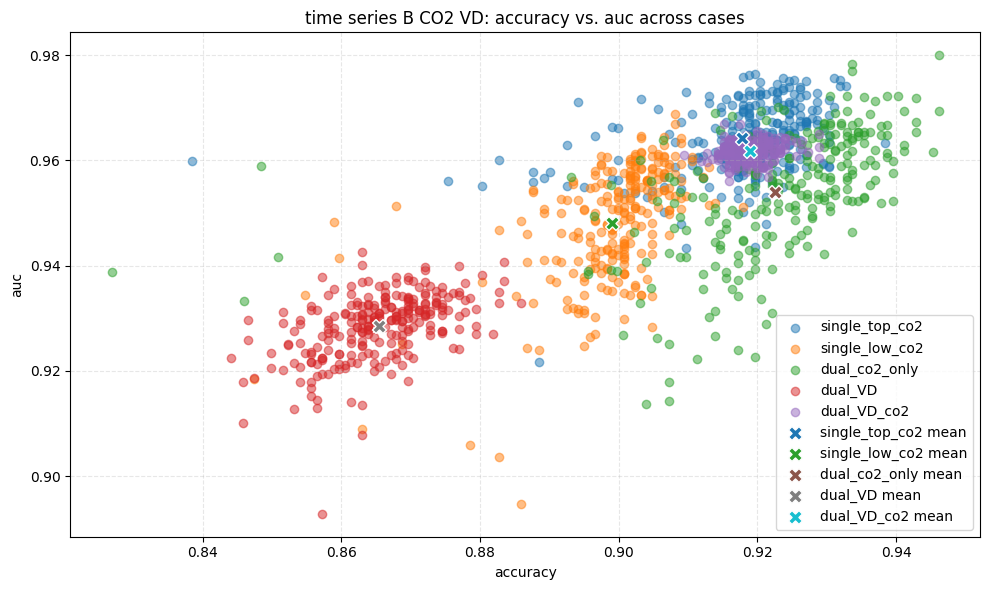

In [76]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

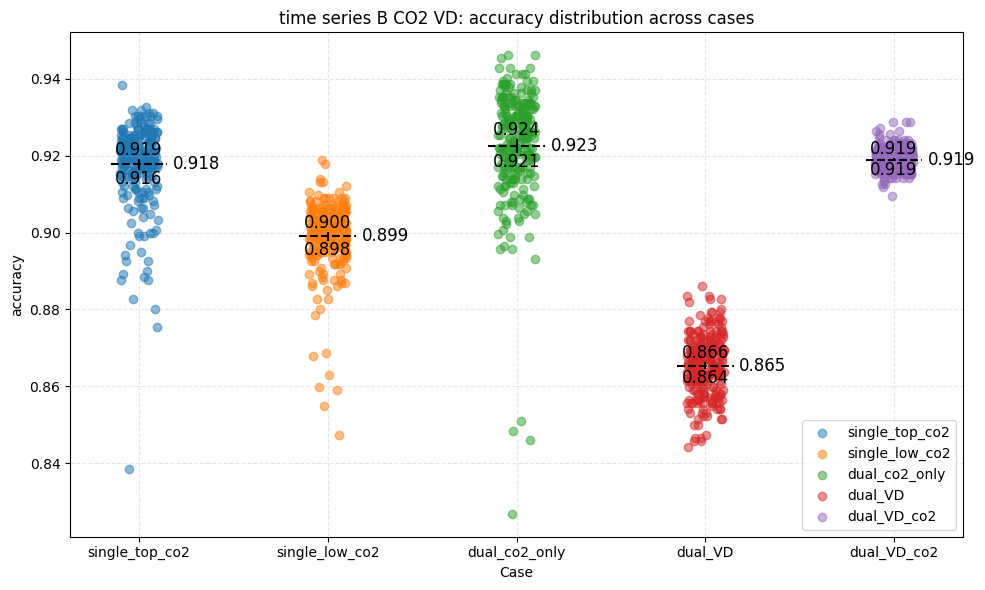

In [77]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

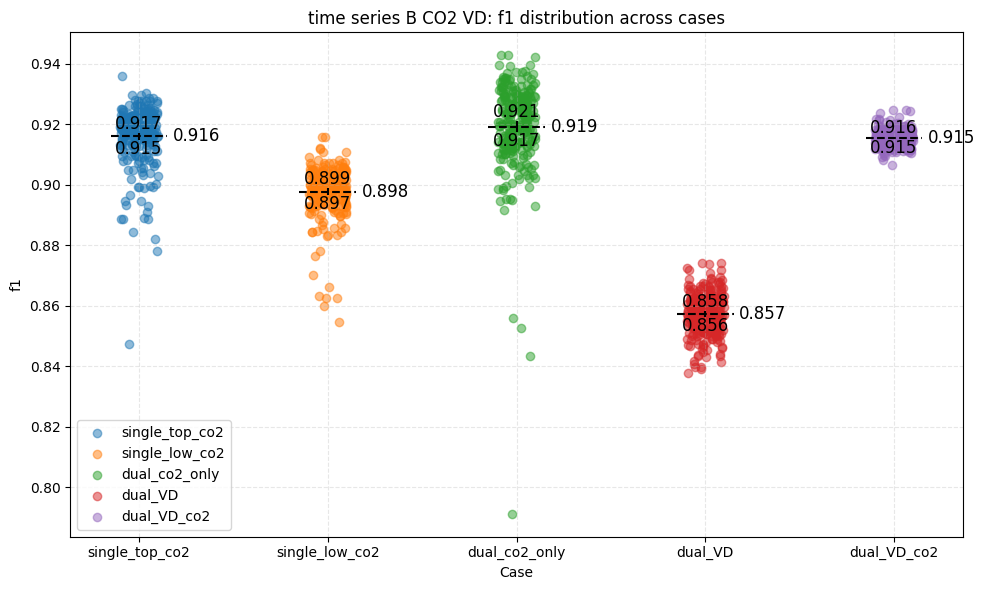

In [78]:
# plot f1 score
metric = "f1"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

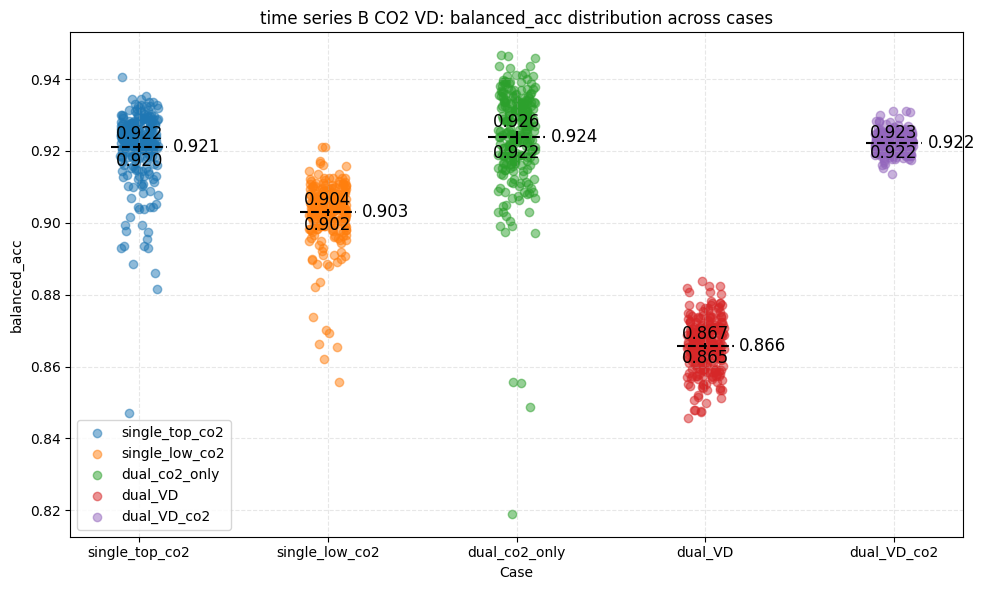

In [79]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

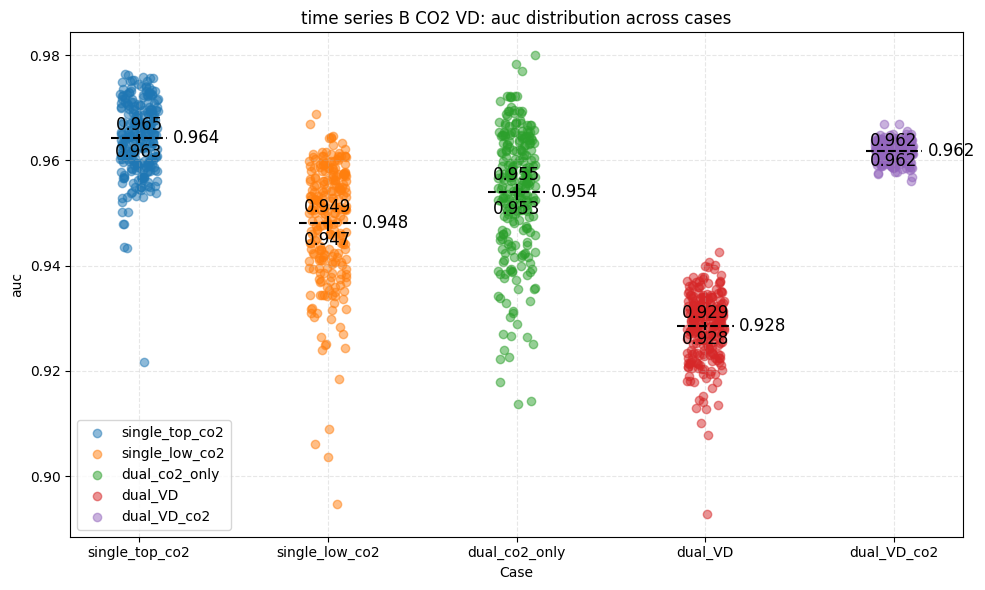

In [80]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [81]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time series B CO2 VD

=== Normality test (D’Agostino and Pearson) for accuracy ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.7695	→	OK normal
dual_VD_co2              :	p = 0.0004	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.6075	→	OK normal
dual_VD_co2              :	p = 0.0002	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
single_top_co2           :	A² = 12.1987,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 10.7564,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 6.5421,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 0.3538,	5% critical = 0.7750	→	OK normal
dual

In [82]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1',
    group_order=case_order
)

time series B CO2 VD

=== Normality test (D’Agostino and Pearson) for f1 ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.3676	→	OK normal
dual_VD_co2              :	p = 0.0022	→	not normal

=== Normality test (Shapiro-Wilk) for f1 ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.3993	→	OK normal
dual_VD_co2              :	p = 0.0069	→	not normal

=== Normality test (Anderson-Darling) for f1 ===
single_top_co2           :	A² = 10.6459,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 9.9294,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 7.6073,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 0.3452,	5% critical = 0.7750	→	OK normal
dual_VD_co2            

In [83]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time series B CO2 VD

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.4768	→	OK normal
dual_VD_co2              :	p = 0.0040	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.5666	→	OK normal
dual_VD_co2              :	p = 0.0110	→	not normal

=== Normality test (Anderson-Darling) for balanced_acc ===
single_top_co2           :	A² = 11.6838,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 10.5822,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 7.0689,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 0.2924,	5% critical = 0.7750	→	OK

In [84]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time series B CO2 VD

=== Normality test (D’Agostino and Pearson) for auc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.1482	→	OK normal

=== Normality test (Shapiro-Wilk) for auc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0811	→	OK normal

=== Normality test (Anderson-Darling) for auc ===
single_top_co2           :	A² = 1.0978,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 3.6383,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 2.7473,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 2.4388,	5% critical = 0.7750	→	not normal
dual_VD_co2         

### ANOVA

In [85]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time series B CO2 VD

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2           F  p-unc      np2
  case      4 560.023569 2715.892781    0.0 0.821835

Effect size (partial η², np2) = 0.8218 → large effect

=== Games-Howell post-hoc test for accuracy ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval    hedges
       dual_VD    dual_VD_co2 0.865368 0.918952 -0.053584 0.000530 -101.032307 319.644432 1.199041e-14 -9.022988
       dual_VD  dual_co2_only 0.865368 0.922595 -0.057227 0.001063  -53.822328 377.390240 7.827072e-14 -4.806762
       dual_VD single_low_co2 0.865368 0.899071 -0.033703 0.000761  -44.271273 486.739240 7.915890e-14 -3.953777
       dual_VD single_top_co2 0.865368 0.917723 -0.052354 0.000851  -61.550263 451.528993 2.319256e-13 -5.496928
   dual_VD_co2  dual_co2_only 0.918952 0.922595 -0.003643 0.000959   -3.796842 268.996575 1.686440e-03 -0.339088
   dual_VD_co2 single_low_co2 0.918952 0.899071  0.019881

In [86]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1'
)

time series B CO2 VD

=== Welch ANOVA for f1 ===
Source  ddof1      ddof2           F  p-unc      np2
  case      4 563.195466 3819.851338    0.0 0.853246

Effect size (partial η², np2) = 0.8532 → large effect

=== Games-Howell post-hoc test for f1 ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.857221 0.915396 -0.058175 0.000480 -121.142825 329.549398 0.000000e+00 -10.819017
       dual_VD  dual_co2_only 0.857221 0.919206 -0.061985 0.001066  -58.131445 349.396787 3.301803e-13  -5.191600
       dual_VD single_low_co2 0.857221 0.897715 -0.040495 0.000697  -58.105474 481.395517 0.000000e+00  -5.189281
       dual_VD single_top_co2 0.857221 0.915966 -0.058745 0.000773  -75.961712 446.742586 0.000000e+00  -6.783985
   dual_VD_co2  dual_co2_only 0.915396 0.919206 -0.003810 0.000986   -3.864247 266.405748 1.311166e-03  -0.345108
   dual_VD_co2 single_low_co2 0.915396 0.897715  0.017681 0.000

In [87]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time series B CO2 VD

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2           F  p-unc      np2
  case      4 558.704487 3499.686247    0.0 0.843955

Effect size (partial η², np2) = 0.8440 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.865793 0.922209 -0.056416 0.000488 -115.719669 320.418736 3.408385e-14 -10.334686
       dual_VD  dual_co2_only 0.865793 0.923887 -0.058094 0.001025  -56.693858 364.521340 0.000000e+00  -5.063212
       dual_VD single_low_co2 0.865793 0.902883 -0.037090 0.000715  -51.852461 480.711400 2.376987e-13  -4.630837
       dual_VD single_top_co2 0.865793 0.921018 -0.055225 0.000791  -69.831702 447.201483 3.441691e-14  -6.236526
   dual_VD_co2  dual_co2_only 0.922209 0.923887 -0.001678 0.000934   -1.795800 266.923443 3.781568e-01  -0.160379
   dual_VD_co2 single_low_co2 0.922209 0.90

In [88]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time series B CO2 VD

=== Welch ANOVA for auc ===
Source  ddof1      ddof2           F         p-unc      np2
  case      4 536.416978 1690.808786 2.006219e-302 0.690801

Effect size (partial η², np2) = 0.6908 → large effect

=== Games-Howell post-hoc test for auc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.928488 0.961765 -0.033277 0.000417 -79.836300 288.374791 3.497203e-14 -7.130016
       dual_VD  dual_co2_only 0.928488 0.953999 -0.025511 0.000860 -29.651340 377.431964 3.141931e-14 -2.648100
       dual_VD single_low_co2 0.928488 0.948062 -0.019574 0.000818 -23.935766 392.422613 1.708633e-13 -2.137654
       dual_VD single_top_co2 0.928488 0.964164 -0.035676 0.000601 -59.313143 492.013034 1.848521e-13 -5.297135
   dual_VD_co2  dual_co2_only 0.961765 0.953999  0.007766 0.000769  10.092215 260.002100 0.000000e+00  0.901315
   dual_VD_co2 single_low_co2 0.961765 0.948062  0.013704 0

## Time independent - C

In [89]:
model = "time independent C CO2 VD"
single_top_co2 = pd.read_csv("../../analysis_sensor_position/_timeindep_results_raw/case_LabEEE_C_top_state_timeindep_co2.csv")
single_low_co2 = pd.read_csv("../../analysis_sensor_position/_timeindep_results_raw/case_LabEEE_C_mid_state_timeindep_co2.csv")
dual_co2_only = pd.read_csv("../_timeindep_results_raw/case_LabEEE_C_state_timeindep_co2only.csv")
dual_VD = pd.read_csv("../_timeindep_results_raw/case_LabEEE_C_state_timeindep_VD.csv")
dual_VD_co2 = pd.read_csv("../_timeindep_results_raw/case_LabEEE_C_state_timeindep_VDco2.csv")

In [90]:
single_top_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.887916,0.006847,0.871279,0.882743,0.888174,0.893001,0.905873
f1_weighted,250.0,0.886649,0.006964,0.869477,0.881798,0.886915,0.891797,0.905093
balanced_acc,250.0,0.863261,0.008225,0.841779,0.857969,0.862978,0.869388,0.886970
auc,250.0,0.932719,0.006697,0.913849,0.928756,0.932593,0.937374,0.949220
model_weights.random_forest,250.0,2.028166,0.266401,1.242942,1.883650,2.054170,2.200535,2.567762
model_weights.bagging_svc,250.0,0.010509,0.150964,-0.421631,-0.092745,0.004998,0.116187,0.551331
model_weights.bagging_knn,250.0,0.171851,0.190721,-0.367027,0.046798,0.180646,0.303463,0.697791
model_weights.gradient_boosting,250.0,2.462753,0.261276,1.759827,2.266124,2.476814,2.634481,3.342166


In [91]:
single_low_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.888692,0.008045,0.864039,0.883347,0.888978,0.894610,0.907482
f1_weighted,250.0,0.887124,0.008231,0.861231,0.881244,0.886819,0.893283,0.906683
balanced_acc,250.0,0.861931,0.009811,0.827417,0.854088,0.862326,0.869193,0.888405
auc,250.0,0.930672,0.007189,0.906647,0.926186,0.931040,0.935854,0.949033
model_weights.random_forest,250.0,1.040113,0.342215,0.237438,0.779696,1.022028,1.254203,1.987678
model_weights.bagging_svc,250.0,-0.200929,0.181659,-0.688071,-0.328939,-0.205648,-0.077033,0.279486
model_weights.bagging_knn,250.0,0.523743,0.184612,0.064031,0.397200,0.536622,0.640198,1.067804
model_weights.gradient_boosting,250.0,2.733295,0.299264,1.904467,2.547341,2.726139,2.943646,3.969767


In [92]:
dual_co2_only.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.925757,0.006556,0.903459,0.921158,0.925583,0.930813,0.946098
f1_weighted,250.0,0.925477,0.006633,0.902519,0.920641,0.925397,0.930490,0.945888
balanced_acc,250.0,0.912660,0.008498,0.881002,0.906526,0.912561,0.918295,0.936163
auc,250.0,0.969960,0.004387,0.957101,0.967244,0.969928,0.973615,0.980454
model_weights.random_forest,250.0,2.532840,0.372342,1.678113,2.279820,2.514035,2.776324,3.510874
model_weights.bagging_svc,250.0,-0.296358,0.284266,-1.094045,-0.482618,-0.286823,-0.131105,0.837824
model_weights.bagging_knn,250.0,-0.711009,0.209591,-1.395896,-0.844264,-0.703804,-0.588633,-0.013696
model_weights.gradient_boosting,250.0,3.221516,0.289019,2.403893,3.013145,3.218789,3.438641,3.955858


In [93]:
dual_VD.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.806092,0.010468,0.774739,0.799075,0.806114,0.813958,0.836685
f1_weighted,250.0,0.796639,0.011437,0.765594,0.788423,0.797389,0.804151,0.828077
balanced_acc,250.0,0.746164,0.012907,0.709632,0.736928,0.747085,0.754530,0.781066
auc,250.0,0.840526,0.010867,0.806490,0.833752,0.840096,0.847723,0.875497
model_weights.random_forest,250.0,1.278977,0.313664,-0.119392,1.095277,1.306627,1.492067,1.973568
model_weights.bagging_svc,250.0,-0.322359,0.115348,-0.675182,-0.402947,-0.323909,-0.245695,-0.052277
model_weights.bagging_knn,250.0,0.136212,0.248894,-0.470678,-0.039899,0.127652,0.310679,0.838326
model_weights.gradient_boosting,250.0,2.358906,0.286794,1.613017,2.185344,2.352326,2.532616,3.296621


In [94]:
dual_VD_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.931878,0.006142,0.917136,0.927595,0.931617,0.936444,0.947707
f1_weighted,250.0,0.931676,0.006184,0.917026,0.927366,0.931576,0.936306,0.947613
balanced_acc,250.0,0.920287,0.007556,0.901692,0.914587,0.920339,0.925658,0.939441
auc,250.0,0.974282,0.004087,0.959293,0.971512,0.974520,0.977098,0.985182
model_weights.random_forest,250.0,2.290302,0.375075,1.221813,2.064110,2.292162,2.547170,3.387801
model_weights.bagging_svc,250.0,-0.323145,0.232761,-0.893356,-0.467853,-0.319007,-0.165873,0.236165
model_weights.bagging_knn,250.0,-0.896684,0.192939,-1.417086,-1.023842,-0.885114,-0.771265,-0.344093
model_weights.gradient_boosting,250.0,3.818149,0.277384,3.173866,3.625677,3.812996,3.962492,4.722947


In [95]:
single_top_co2['case'] = 'single_top_co2'
single_low_co2['case'] = 'single_low_co2'
dual_co2_only['case'] = 'dual_co2_only'
dual_VD['case'] = 'dual_VD'
dual_VD_co2['case'] = 'dual_VD_co2'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        single_top_co2[metrics],
        single_low_co2[metrics],
        dual_co2_only[metrics],
        dual_VD[metrics],
        dual_VD_co2[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1250 non-null   object 
 1   accuracy      1250 non-null   float64
 2   f1_weighted   1250 non-null   float64
 3   balanced_acc  1250 non-null   float64
 4   auc           1250 non-null   float64
dtypes: float64(4), object(1)
memory usage: 49.0+ KB


In [96]:
case_order = ['single_top_co2', 'single_low_co2', 'dual_co2_only', 'dual_VD', 'dual_VD_co2']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,single_top_co2,single_top_co2,single_top_co2,single_top_co2,single_top_co2
accuracy,0.890587,0.892196,0.879324,0.88576,0.882542
f1_weighted,0.889277,0.890744,0.877539,0.884065,0.880455
balanced_acc,0.8679,0.868353,0.85185,0.862689,0.850486
auc,0.93458,0.937915,0.924231,0.929966,0.936137
x,0,0,0,0,0
x_jitter,-0.076207,0.033179,-0.015143,0.07302,-0.033799


### plot

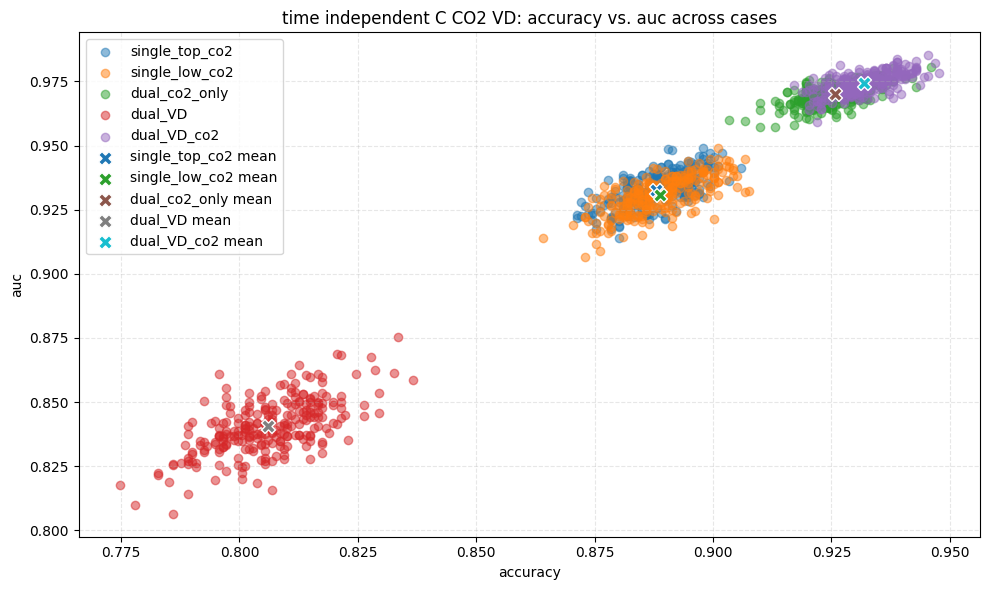

In [97]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

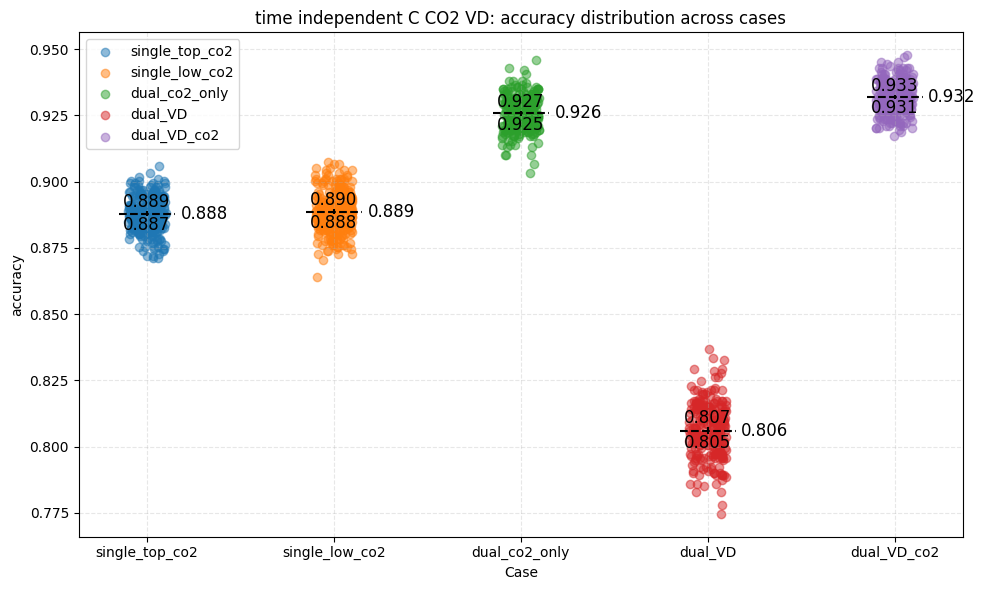

In [98]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

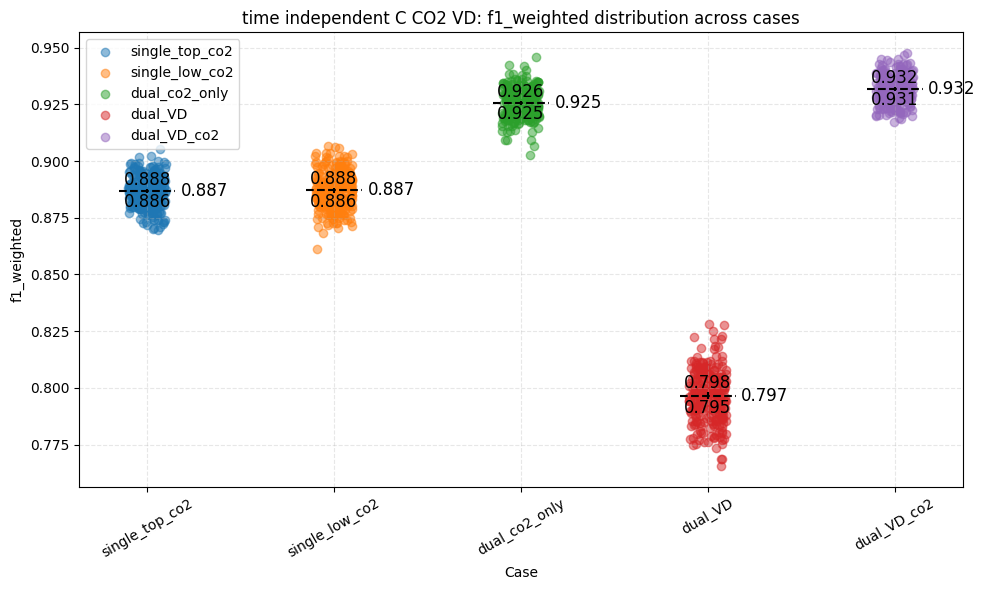

In [99]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order, rotation=30)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

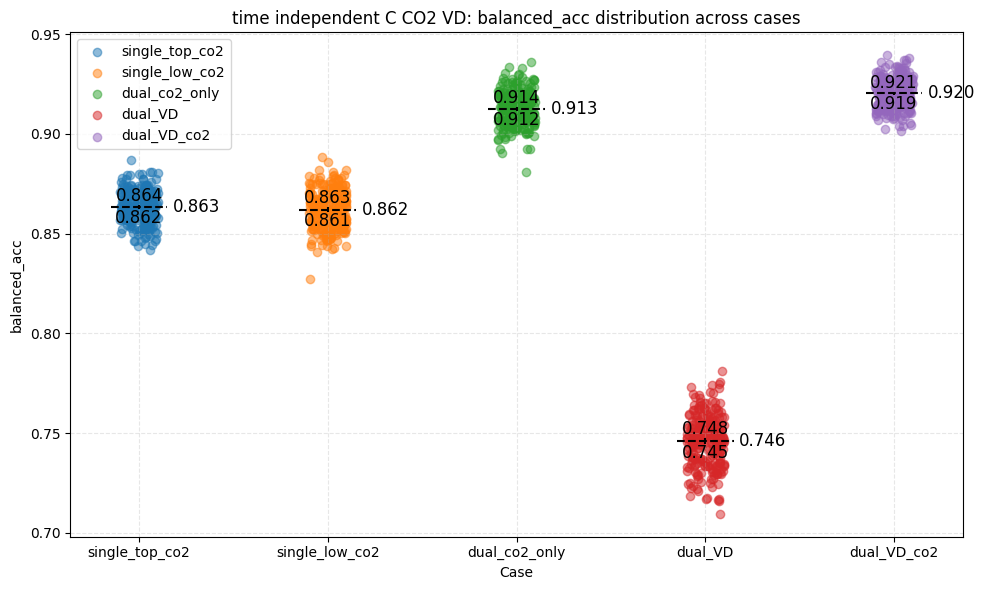

In [100]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

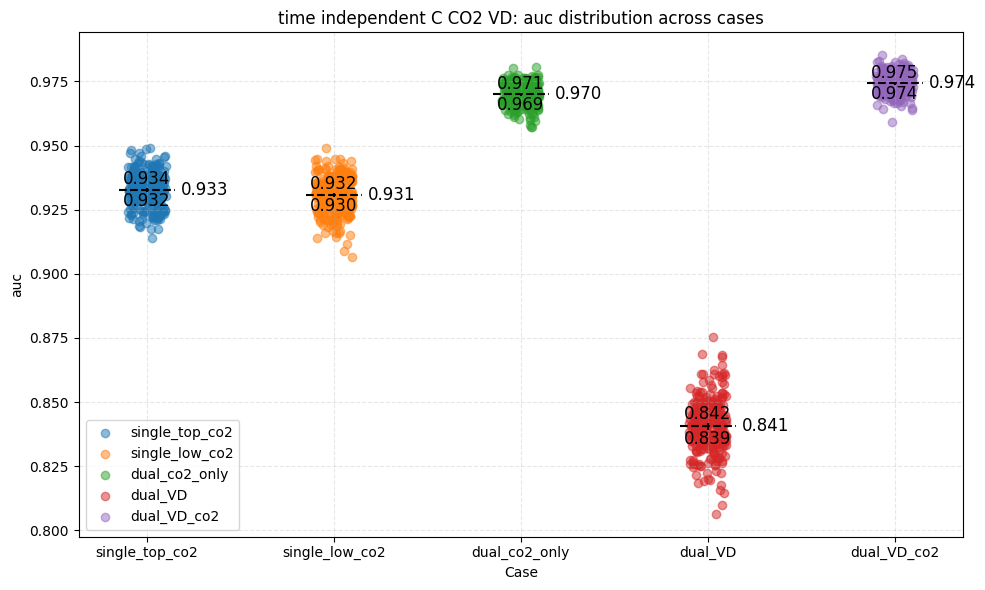

In [101]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [102]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent C CO2 VD

=== Normality test (D’Agostino and Pearson) for accuracy ===
single_top_co2           :	p = 0.2368	→	OK normal
single_low_co2           :	p = 0.4005	→	OK normal
dual_co2_only            :	p = 0.4371	→	OK normal
dual_VD                  :	p = 0.9305	→	OK normal
dual_VD_co2              :	p = 0.0817	→	OK normal

=== Normality test (Shapiro-Wilk) for accuracy ===
single_top_co2           :	p = 0.2364	→	OK normal
single_low_co2           :	p = 0.3142	→	OK normal
dual_co2_only            :	p = 0.2601	→	OK normal
dual_VD                  :	p = 0.8176	→	OK normal
dual_VD_co2              :	p = 0.1583	→	OK normal

=== Normality test (Anderson-Darling) for accuracy ===
single_top_co2           :	A² = 0.4381,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 0.4229,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.5500,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.3200,	5% critical = 0.7750	→	OK normal
dual_VD_co2 

In [103]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent C CO2 VD

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
single_top_co2           :	p = 0.2627	→	OK normal
single_low_co2           :	p = 0.4261	→	OK normal
dual_co2_only            :	p = 0.4113	→	OK normal
dual_VD                  :	p = 0.9835	→	OK normal
dual_VD_co2              :	p = 0.0819	→	OK normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
single_top_co2           :	p = 0.4638	→	OK normal
single_low_co2           :	p = 0.4245	→	OK normal
dual_co2_only            :	p = 0.4397	→	OK normal
dual_VD                  :	p = 0.6241	→	OK normal
dual_VD_co2              :	p = 0.2792	→	OK normal

=== Normality test (Anderson-Darling) for f1_weighted ===
single_top_co2           :	A² = 0.2870,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 0.3556,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.3755,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.3150,	5% critical = 0.7750	→	OK normal
dua

In [104]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent C CO2 VD

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
single_top_co2           :	p = 0.7126	→	OK normal
single_low_co2           :	p = 0.7177	→	OK normal
dual_co2_only            :	p = 0.4460	→	OK normal
dual_VD                  :	p = 0.6645	→	OK normal
dual_VD_co2              :	p = 0.1804	→	OK normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
single_top_co2           :	p = 0.8098	→	OK normal
single_low_co2           :	p = 0.1875	→	OK normal
dual_co2_only            :	p = 0.6276	→	OK normal
dual_VD                  :	p = 0.8073	→	OK normal
dual_VD_co2              :	p = 0.5133	→	OK normal

=== Normality test (Anderson-Darling) for balanced_acc ===
single_top_co2           :	A² = 0.2502,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 0.6183,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.1982,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.3295,	5% critical = 0.7750	→	OK normal


In [105]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent C CO2 VD

=== Normality test (D’Agostino and Pearson) for auc ===
single_top_co2           :	p = 0.6731	→	OK normal
single_low_co2           :	p = 0.0446	→	not normal
dual_co2_only            :	p = 0.1167	→	OK normal
dual_VD                  :	p = 0.3197	→	OK normal
dual_VD_co2              :	p = 0.1924	→	OK normal

=== Normality test (Shapiro-Wilk) for auc ===
single_top_co2           :	p = 0.5596	→	OK normal
single_low_co2           :	p = 0.0878	→	OK normal
dual_co2_only            :	p = 0.0153	→	not normal
dual_VD                  :	p = 0.6340	→	OK normal
dual_VD_co2              :	p = 0.6249	→	OK normal

=== Normality test (Anderson-Darling) for auc ===
single_top_co2           :	A² = 0.3725,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 0.5488,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.8670,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 0.4138,	5% critical = 0.7750	→	OK normal
dual_VD_co2             

### ANOVA

In [106]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent C CO2 VD

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2           F  p-unc      np2
  case      4 618.488674 7955.094198    0.0 0.970981

Effect size (partial η², np2) = 0.9710 → large effect

=== Games-Howell post-hoc test for accuracy ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.806092 0.931878 -0.125786 0.000768 -163.869526 402.274775 6.095124e-14 -14.634851
       dual_VD  dual_co2_only 0.806092 0.925757 -0.119665 0.000781 -153.186683 418.284272 1.426637e-13 -13.680788
       dual_VD single_low_co2 0.806092 0.888692 -0.082600 0.000835  -98.925662 467.056175 0.000000e+00  -8.834848
       dual_VD single_top_co2 0.806092 0.887916 -0.081825 0.000791 -103.432799 429.084360 0.000000e+00  -9.237371
   dual_VD_co2  dual_co2_only 0.931878 0.925757  0.006121 0.000568   10.772741 495.896551 1.479927e-13   0.962091
   dual_VD_co2 single_low_co2 0.931878 0.88869

In [107]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent C CO2 VD

=== Welch ANOVA for f1_weighted ===
Source  ddof1      ddof2           F  p-unc      np2
  case      4 617.640583 8007.484002    0.0 0.972574

Effect size (partial η², np2) = 0.9726 → large effect

=== Games-Howell post-hoc test for f1_weighted ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.796639 0.931676 -0.135037 0.000822 -164.215532 383.118548 1.365574e-13 -14.665752
       dual_VD  dual_co2_only 0.796639 0.925477 -0.128839 0.000836 -154.075852 399.475640 3.042011e-14 -13.760198
       dual_VD single_low_co2 0.796639 0.887124 -0.090486 0.000891 -101.533220 452.363215 1.380007e-13  -9.067724
       dual_VD single_top_co2 0.796639 0.886649 -0.090010 0.000847 -106.280898 411.327669 6.328271e-14  -9.491729
   dual_VD_co2  dual_co2_only 0.931676 0.925477  0.006199 0.000574   10.807571 495.571023 2.291500e-13   0.965202
   dual_VD_co2 single_low_co2 0.931676 0

In [108]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent C CO2 VD

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2           F  p-unc      np2
  case      4 618.603114 9852.980647    0.0 0.976912

Effect size (partial η², np2) = 0.9769 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.746164 0.920287 -0.174123 0.000946 -184.084957 401.743222 5.229150e-14 -16.440250
       dual_VD  dual_co2_only 0.746164 0.912660 -0.166497 0.000977 -170.358737 430.732252 1.491030e-13 -15.214389
       dual_VD single_low_co2 0.746164 0.861931 -0.115767 0.001025 -112.906132 464.724343 1.776357e-13 -10.083415
       dual_VD single_top_co2 0.746164 0.863261 -0.117098 0.000968 -120.976259 422.602383 0.000000e+00 -10.804142
   dual_VD_co2  dual_co2_only 0.920287 0.912660  0.007627 0.000719   10.604495 491.284060 2.567946e-13   0.947066
   dual_VD_co2 single_low_co2 0.920287

In [109]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent C CO2 VD

=== Welch ANOVA for auc ===
Source  ddof1      ddof2            F  p-unc      np2
  case      4 608.137673 10426.118218    0.0 0.978886

Effect size (partial η², np2) = 0.9789 → large effect

=== Games-Howell post-hoc test for auc ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.840526 0.974282 -0.133756 0.000734 -182.150161 318.060731 0.000000e+00 -16.267457
       dual_VD  dual_co2_only 0.840526 0.969960 -0.129434 0.000741 -174.626940 328.054883 0.000000e+00 -15.595574
       dual_VD single_low_co2 0.840526 0.930672 -0.090146 0.000824 -109.390506 431.887261 3.049783e-13  -9.769442
       dual_VD single_top_co2 0.840526 0.932719 -0.092192 0.000807 -114.192749 414.285603 2.096101e-13 -10.198320
   dual_VD_co2  dual_co2_only 0.974282 0.969960  0.004322 0.000379   11.396885 495.525957 3.573808e-13   1.017832
   dual_VD_co2 single_low_co2 0.974282 0.930672  0.043

## Time series - C

In [110]:
model = "time series C CO2 VD"
single_top_co2 = pd.read_csv("../../analysis_sensor_position/_timeseries_results_raw/case_LabEEE_C_top_state_timeseries_co2.csv")
single_low_co2 = pd.read_csv("../../analysis_sensor_position/_timeseries_results_raw/case_LabEEE_C_mid_state_timeseries_co2.csv")
dual_co2_only = pd.read_csv("../_timeseries_results_raw/case_LabEEE_C_state_timeseries_co2only.csv")
dual_VD = pd.read_csv("../_timeseries_results_raw/case_LabEEE_C_state_timeseries_VD.csv")
dual_VD_co2 = pd.read_csv("../_timeseries_results_raw/case_LabEEE_C_state_timeseries_VDco2.csv")

In [111]:
single_top_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.910727,0.009415,0.857959,0.908571,0.913469,0.916735,0.928163
f1,250.0,0.907972,0.008465,0.862342,0.905629,0.910486,0.913256,0.924269
balanced_acc,250.0,0.913823,0.008595,0.865634,0.911617,0.916506,0.919130,0.929767
auc,250.0,0.948625,0.005867,0.911187,0.946368,0.949692,0.952212,0.960129
feature_importance.C_top_CO2_scaled,250.0,-0.000427,0.007105,-0.048571,-0.002755,0.000163,0.003429,0.020490
feature_importance.C_top_CO2_fd1_scaled,250.0,0.144958,0.044493,0.040490,0.113469,0.143184,0.174408,0.259918
feature_importance.C_top_CO2_fd2_scaled,250.0,0.158647,0.047907,0.030122,0.129224,0.160980,0.194612,0.279265
feature_importance.C_top_CO2_fd3_scaled,250.0,0.093921,0.047635,0.005959,0.056592,0.087959,0.127694,0.211918


In [112]:
single_low_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.910681,0.002550,0.900894,0.909017,0.910642,0.912266,0.921202
f1,250.0,0.905105,0.002978,0.893543,0.903282,0.905009,0.906736,0.917165
balanced_acc,250.0,0.912008,0.002782,0.901296,0.910279,0.911942,0.913630,0.923419
auc,250.0,0.950091,0.005614,0.930854,0.946971,0.951010,0.953968,0.961663
feature_importance.C_mid_CO2_scaled,250.0,-0.000030,0.002729,-0.005118,-0.002031,-0.000406,0.001686,0.012185
feature_importance.C_mid_CO2_fd1_scaled,250.0,0.130674,0.035301,0.031032,0.106803,0.130504,0.151056,0.244192
feature_importance.C_mid_CO2_fd2_scaled,250.0,0.114194,0.039003,0.024370,0.085418,0.112998,0.137754,0.234687
feature_importance.C_mid_CO2_fd3_scaled,250.0,0.105502,0.045242,0.008773,0.071893,0.102234,0.136231,0.247116


In [113]:
dual_co2_only.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.923376,0.005099,0.906580,0.920390,0.923639,0.926889,0.941511
f1,250.0,0.918539,0.005708,0.900260,0.915386,0.918685,0.922156,0.938250
balanced_acc,250.0,0.924751,0.005410,0.907490,0.921749,0.924866,0.928192,0.943530
auc,250.0,0.952999,0.004579,0.937434,0.950021,0.953245,0.956131,0.965580
feature_importance.C_mid_CO2_scaled,250.0,0.002604,0.004256,-0.012916,0.000020,0.002721,0.004996,0.023071
feature_importance.C_mid_CO2_fd1_scaled,250.0,0.058056,0.029373,0.001950,0.036495,0.055768,0.076015,0.165881
feature_importance.C_mid_CO2_fd2_scaled,250.0,0.054740,0.029736,0.001950,0.032535,0.052518,0.071040,0.153290
feature_importance.C_mid_CO2_fd3_scaled,250.0,0.019017,0.017602,-0.003737,0.006418,0.013891,0.027295,0.116653


In [114]:
dual_VD.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.839021,0.008487,0.799670,0.835120,0.840066,0.844188,0.856554
f1,250.0,0.817251,0.010539,0.772773,0.811696,0.818482,0.823965,0.840074
balanced_acc,250.0,0.834804,0.008698,0.800598,0.830292,0.835721,0.840543,0.853499
auc,250.0,0.868704,0.008371,0.833981,0.863944,0.869245,0.874068,0.889102
feature_importance.C_CO2_vd_scaled,250.0,-0.000308,0.005088,-0.023413,-0.002617,-0.000247,0.001958,0.035862
feature_importance.C_CO2_vd_fd1_scaled,250.0,0.045777,0.023122,0.004452,0.028957,0.042045,0.059893,0.120857
feature_importance.C_CO2_vd_fd2_scaled,250.0,0.077602,0.029578,-0.005194,0.055420,0.076051,0.096290,0.192168
feature_importance.C_CO2_vd_fd3_scaled,250.0,0.065715,0.028258,0.004782,0.046620,0.061418,0.080441,0.196620


In [115]:
dual_VD_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.921940,0.009646,0.837530,0.920390,0.922827,0.926076,0.933387
f1,250.0,0.917567,0.009106,0.838969,0.915393,0.918315,0.921619,0.929795
balanced_acc,250.0,0.923748,0.009135,0.843945,0.921743,0.924518,0.927656,0.935486
auc,250.0,0.952159,0.007269,0.919902,0.947965,0.953135,0.956917,0.971960
feature_importance.C_CO2_vd_scaled,250.0,0.000790,0.004517,-0.029001,-0.000812,0.000325,0.001604,0.028026
feature_importance.C_CO2_vd_fd1_scaled,250.0,0.002466,0.005252,-0.003737,-0.000325,0.000894,0.003493,0.037124
feature_importance.C_CO2_vd_fd2_scaled,250.0,0.002451,0.004758,-0.014135,0.000020,0.001219,0.003737,0.035012
feature_importance.C_CO2_vd_fd3_scaled,250.0,0.001859,0.003830,-0.010804,-0.000325,0.000894,0.003493,0.019009


In [116]:
single_top_co2['case'] = 'single_top_co2'
single_low_co2['case'] = 'single_low_co2'
dual_co2_only['case'] = 'dual_co2_only'
dual_VD['case'] = 'dual_VD'
dual_VD_co2['case'] = 'dual_VD_co2'

metrics = ["case", "accuracy", "f1", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        single_top_co2[metrics],
        single_low_co2[metrics],
        dual_co2_only[metrics],
        dual_VD[metrics],
        dual_VD_co2[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1250 non-null   object 
 1   accuracy      1250 non-null   float64
 2   f1            1250 non-null   float64
 3   balanced_acc  1250 non-null   float64
 4   auc           1250 non-null   float64
dtypes: float64(4), object(1)
memory usage: 49.0+ KB


In [117]:
case_order = ['single_top_co2', 'single_low_co2', 'dual_co2_only', 'dual_VD', 'dual_VD_co2']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,single_top_co2,single_top_co2,single_top_co2,single_top_co2,single_top_co2
accuracy,0.905306,0.857959,0.916735,0.909388,0.894694
f1,0.902848,0.862342,0.913413,0.906487,0.893123
balanced_acc,0.908809,0.865634,0.919288,0.91247,0.898961
auc,0.940931,0.940121,0.954079,0.946718,0.950906
x,0,0,0,0,0
x_jitter,-0.065934,-0.016077,-0.060321,0.074781,-0.046302


### plot

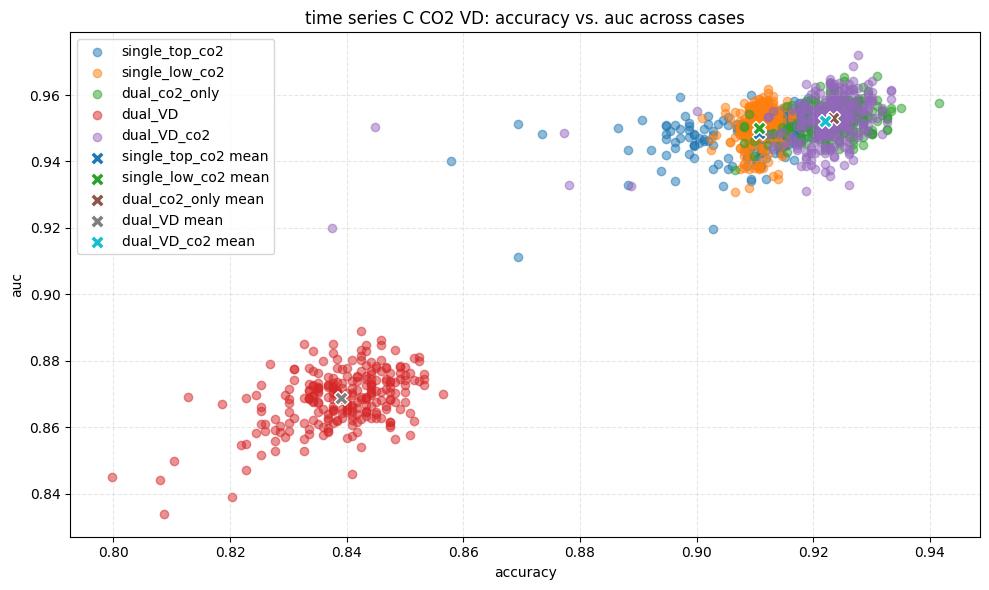

In [118]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

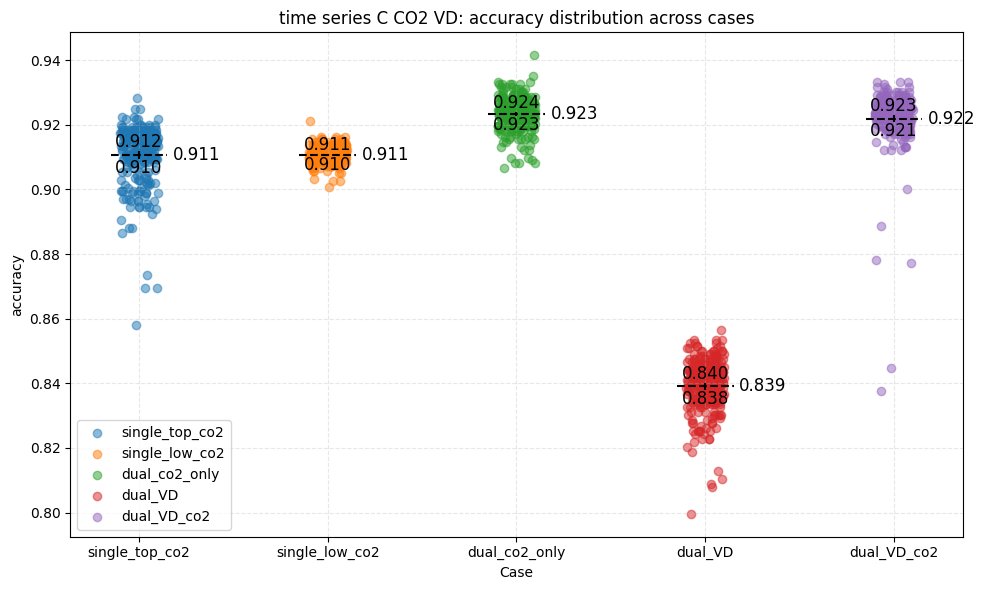

In [119]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

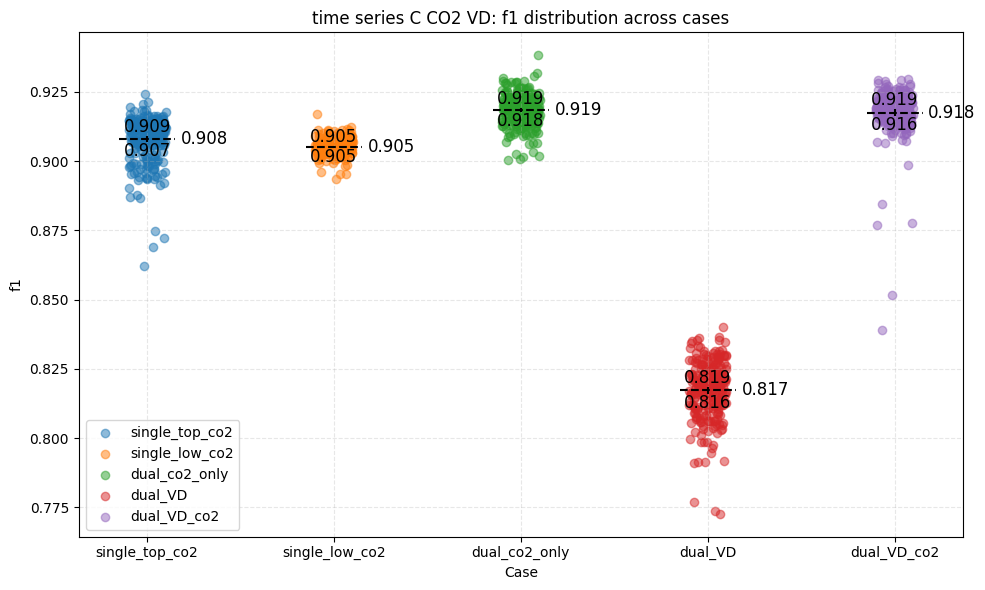

In [120]:
# plot f1 score
metric = "f1"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

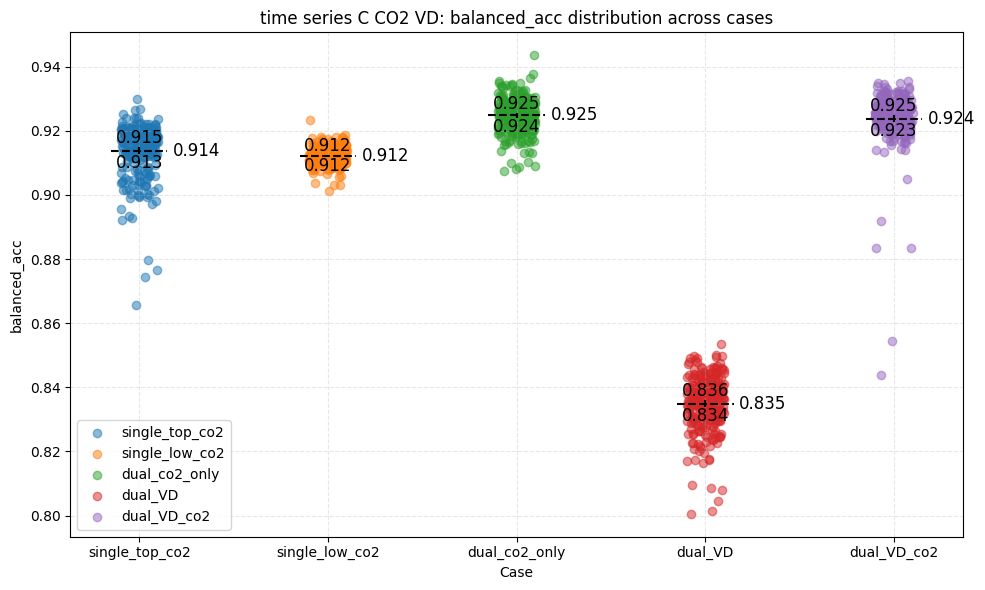

In [121]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

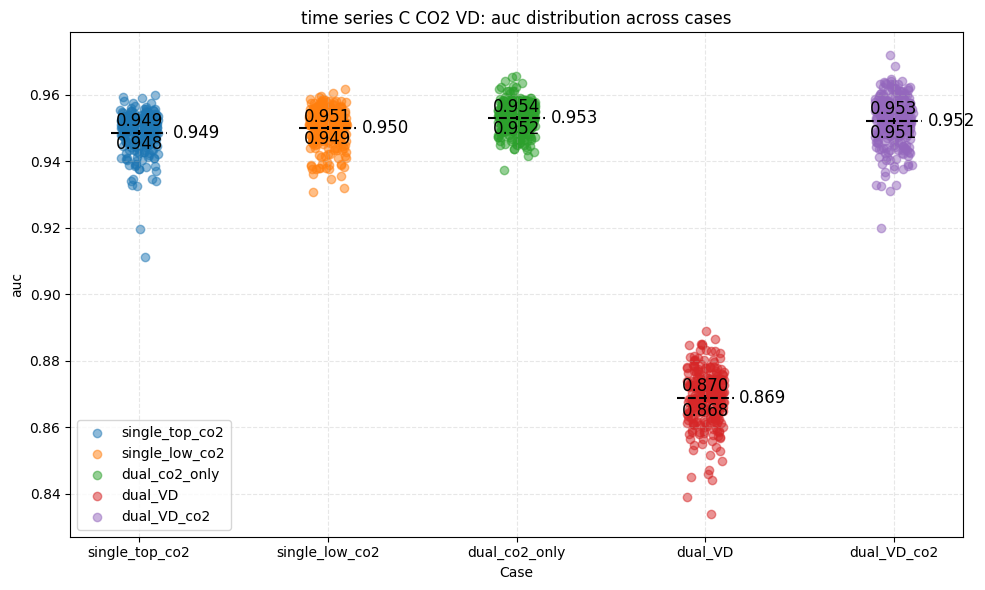

In [122]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [123]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time series C CO2 VD

=== Normality test (D’Agostino and Pearson) for accuracy ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0007	→	not normal
dual_co2_only            :	p = 0.0002	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0001	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
single_top_co2           :	A² = 11.4738,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 1.9943,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 1.8479,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 2.6247,	5% critical = 0.7750	→	not normal
du

In [124]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1',
    group_order=case_order
)

time series C CO2 VD

=== Normality test (D’Agostino and Pearson) for f1 ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0005	→	not normal
dual_co2_only            :	p = 0.0013	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for f1 ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0001	→	not normal
dual_co2_only            :	p = 0.0016	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for f1 ===
single_top_co2           :	A² = 10.3216,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 1.3346,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 1.1869,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 1.5745,	5% critical = 0.7750	→	not normal
dual_VD_co2         

In [125]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time series C CO2 VD

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0005	→	not normal
dual_co2_only            :	p = 0.0022	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0002	→	not normal
dual_co2_only            :	p = 0.0025	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for balanced_acc ===
single_top_co2           :	A² = 11.0688,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 1.3144,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 1.1412,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 1.8936,	5% critical = 0.7750	→	n

In [126]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time series C CO2 VD

=== Normality test (D’Agostino and Pearson) for auc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.7769	→	OK normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.8587	→	OK normal
dual_VD                  :	p = 0.0002	→	not normal
dual_VD_co2              :	p = 0.0002	→	not normal

=== Normality test (Anderson-Darling) for auc ===
single_top_co2           :	A² = 5.4107,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 2.6987,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 0.2162,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.9169,	5% critical = 0.7750	→	not normal
dual_VD_co2          

### ANOVA

In [127]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time series C CO2 VD

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2           F  p-unc      np2
  case      4 570.594688 4870.529157    0.0 0.945741

Effect size (partial η², np2) = 0.9457 → large effect

=== Games-Howell post-hoc test for accuracy ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.839021 0.921940 -0.082919 0.000813 -102.041681 490.059654 2.664535e-13  -9.113133
       dual_VD  dual_co2_only 0.839021 0.923376 -0.084356 0.000626 -134.711822 408.009722 0.000000e+00 -12.030837
       dual_VD single_low_co2 0.839021 0.910681 -0.071660 0.000560 -127.853819 293.588889 1.862954e-13 -11.418362
       dual_VD single_top_co2 0.839021 0.910727 -0.071706 0.000802  -89.445215 492.738391 9.270362e-14  -7.988169
   dual_VD_co2  dual_co2_only 0.921940 0.923376 -0.001436 0.000690   -2.081342 378.058268 2.302982e-01  -0.185880
   dual_VD_co2 single_low_co2 0.921940 0.910681  0.

In [128]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1'
)

time series C CO2 VD

=== Welch ANOVA for f1 ===
Source  ddof1      ddof2           F  p-unc      np2
  case      4 578.739422 4784.210093    0.0 0.960118

Effect size (partial η², np2) = 0.9601 → large effect

=== Games-Howell post-hoc test for f1 ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.817251 0.917567 -0.100316 0.000881 -113.877987 487.724135 1.532108e-14 -10.170209
       dual_VD  dual_co2_only 0.817251 0.918539 -0.101288 0.000758 -133.614204 383.513966 0.000000e+00 -11.932810
       dual_VD single_low_co2 0.817251 0.905105 -0.087854 0.000693 -126.832789 288.514072 1.637579e-13 -11.327176
       dual_VD single_top_co2 0.817251 0.907972 -0.090721 0.000855 -106.111333 475.855877 1.517675e-13  -9.476585
   dual_VD_co2  dual_co2_only 0.917567 0.918539 -0.000972 0.000680   -1.430019 418.522105 6.085954e-01  -0.127712
   dual_VD_co2 single_low_co2 0.917567 0.905105  0.012462 0.000

In [129]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time series C CO2 VD

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2           F  p-unc     np2
  case      4 577.465771 5303.511835    0.0 0.95529

Effect size (partial η², np2) = 0.9553 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.834804 0.923748 -0.088945 0.000798 -111.488919 496.809175 1.652012e-13  -9.956847
       dual_VD  dual_co2_only 0.834804 0.924751 -0.089947 0.000648 -138.839142 416.549190 4.329870e-15 -12.399439
       dual_VD single_low_co2 0.834804 0.912008 -0.077204 0.000578 -133.666200 299.409253 7.760459e-14 -11.937454
       dual_VD single_top_co2 0.834804 0.913823 -0.079019 0.000773 -102.170062 497.928888 0.000000e+00  -9.124599
   dual_VD_co2  dual_co2_only 0.923748 0.924751 -0.001003 0.000671   -1.493066 404.510622 5.675865e-01  -0.133343
   dual_VD_co2 single_low_co2 0.923748 0.9120

In [130]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time series C CO2 VD

=== Welch ANOVA for auc ===
Source  ddof1      ddof2           F  p-unc      np2
  case      4 616.043695 5460.097609    0.0 0.962914

Effect size (partial η², np2) = 0.9629 → large effect

=== Games-Howell post-hoc test for auc ===
             A              B  mean(A)  mean(B)      diff       se           T         df         pval     hedges
       dual_VD    dual_VD_co2 0.868704 0.952159 -0.083455 0.000701 -119.024884 488.396770 3.147482e-13 -10.629868
       dual_VD  dual_co2_only 0.868704 0.952999 -0.084295 0.000603 -139.689783 385.769411 1.409983e-13 -12.475408
       dual_VD single_low_co2 0.868704 0.950091 -0.081387 0.000637 -127.677690 435.292985 3.145262e-13 -11.402633
       dual_VD single_top_co2 0.868704 0.948625 -0.079921 0.000647 -123.619597 446.089531 3.619327e-14 -11.040213
   dual_VD_co2  dual_co2_only 0.952159 0.952999 -0.000840 0.000543   -1.546066 419.735587 5.330576e-01  -0.138076
   dual_VD_co2 single_low_co2 0.952159 0.950091  0.002068 0.0